A Copy from 'Section 5 CNN.ipynb', here we do some tests on the ECQ with CNN
The first thing we are trying is to shuffle the order of aps and see what the saliency changes.

# Section 5 Predict the Order of Vanishing With CNN

## Import libraries and define functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from warnings import simplefilter
#simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

from sklearn.model_selection import train_test_split

import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
#from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#from sage.all import primes_first_n
import torch
import torch.nn as nn
import torch.optim as optim

#from sage.all import is_prime
from utils import build_ap_df
import gc
import pickle
import ast
import math

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
def is_prime(n):
    if n < 2:
        return False
    # Check divisibility up to the square root of n
    for i in np.arange(2, int(np.sqrt(n)) + 1):
        if n % i == 0:
            return False
    return True
    
NUM_ANS = 10000
PRIME_COLUMNS = [str(n+1) for n in range(NUM_ANS) if is_prime(n+1)]

In [4]:
def calculate_accuracy(y_true, y_pred):
    _, predicted = torch.max(y_pred, 1)
    correct = (predicted == y_true).sum().item()
    accuracy = correct / y_true.size(0)
    return accuracy

## Distribution of conductor N

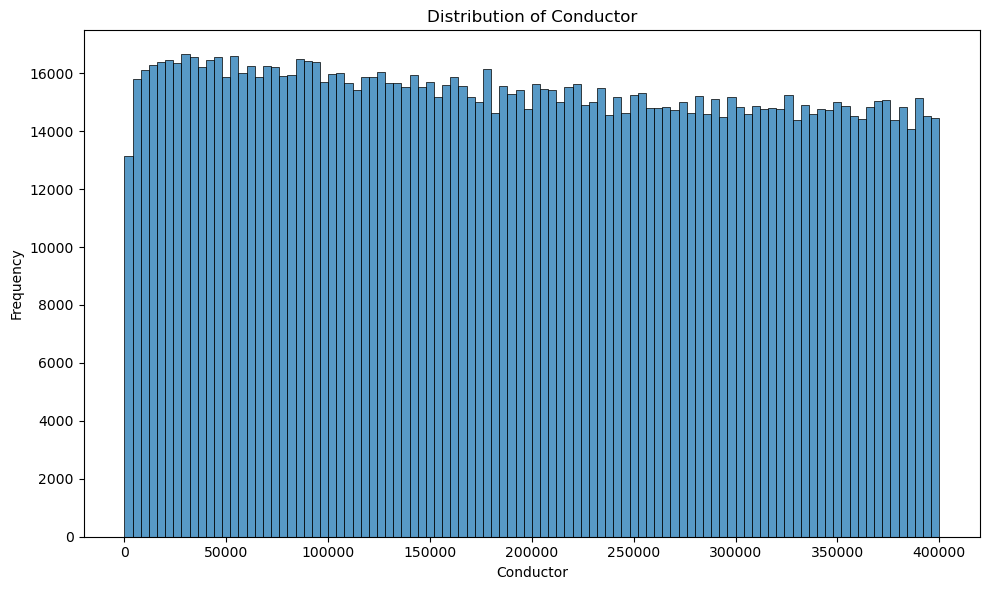

In [8]:
DF_ap = pd.read_csv('ECQ6_DF_ap.csv', usecols=['conductor'])
conductors = DF_ap['conductor'].to_numpy()
del DF_ap
gc.collect()

plt.figure(figsize=(10, 6))

# Create a histogram with 20 bins
sns.histplot(conductors, bins=100)

plt.title('Distribution of Conductor')
plt.xlabel('Conductor')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [40]:
# DF_ap[DF_ap['conductor']==10001] # 36838
# DF_ap[DF_ap['conductor']==100002] # 402856
# DF_ap[DF_ap['conductor']==110001] # 442523
# DF_ap[DF_ap['conductor']==200002] # 791985
# DF_ap[DF_ap['conductor']==210001] # 830890
# DF_ap[DF_ap['conductor']==300001] # 1168364
# DF_ap[DF_ap['conductor']==310002] # 1205106
# DF_ap[DF_ap['conductor']==399998] # 1536782

,conductor
1536782,399998


## Shuffle the order of aps

In [9]:
seed = 11167297796775735125  # Set your desired seed value
torch.manual_seed(seed)
np.random.seed(1234)

### Training

Size of the dataset:  36838
The range of the conductor: [0, 10000]
Epoch [1/60], Loss: 0.9582, Train Accuracy: 0.5199, Test Accuracy: 0.5133
Epoch [2/60], Loss: 0.8641, Train Accuracy: 0.5199, Test Accuracy: 0.5133
Epoch [3/60], Loss: 0.8381, Train Accuracy: 0.7328, Test Accuracy: 0.7239
Epoch [4/60], Loss: 0.7561, Train Accuracy: 0.8096, Test Accuracy: 0.8194
Epoch [5/60], Loss: 0.6102, Train Accuracy: 0.8375, Test Accuracy: 0.8393
Epoch [6/60], Loss: 0.4482, Train Accuracy: 0.8817, Test Accuracy: 0.8846
Epoch [7/60], Loss: 0.3117, Train Accuracy: 0.9256, Test Accuracy: 0.9287
Epoch [8/60], Loss: 0.1993, Train Accuracy: 0.9713, Test Accuracy: 0.9681
Epoch [9/60], Loss: 0.1192, Train Accuracy: 0.9878, Test Accuracy: 0.9864
Epoch [10/60], Loss: 0.0807, Train Accuracy: 0.9910, Test Accuracy: 0.9891
Epoch [11/60], Loss: 0.0628, Train Accuracy: 0.9917, Test Accuracy: 0.9900
Epoch [12/60], Loss: 0.0658, Train Accuracy: 0.9895, Test Accuracy: 0.9881
Epoch [13/60], Loss: 0.0510, Train Accurac

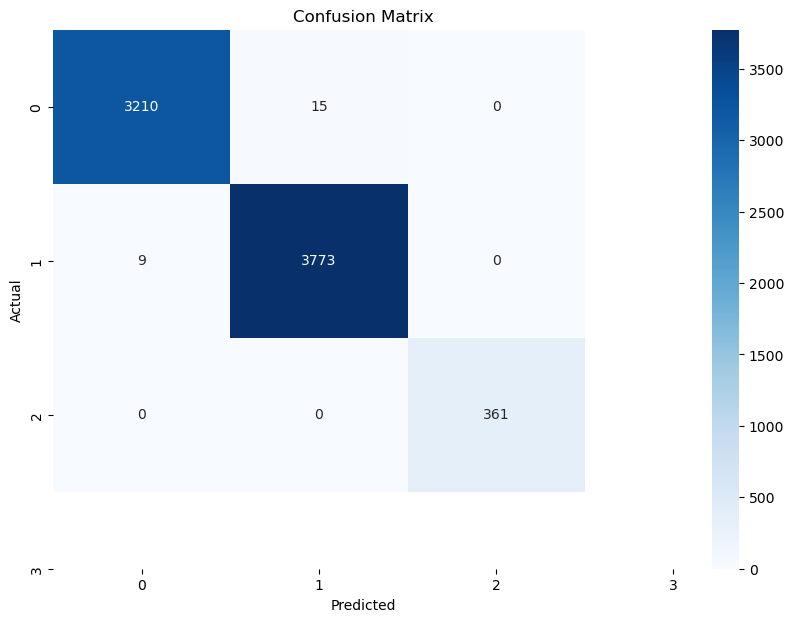

Size of the dataset:  39667
The range of the conductor: [100000, 110000]
Epoch [1/60], Loss: 1.0749, Train Accuracy: 0.5158, Test Accuracy: 0.5208
Epoch [2/60], Loss: 0.9831, Train Accuracy: 0.4994, Test Accuracy: 0.5067
Epoch [3/60], Loss: 0.8750, Train Accuracy: 0.5961, Test Accuracy: 0.6017
Epoch [4/60], Loss: 0.6726, Train Accuracy: 0.7891, Test Accuracy: 0.7988
Epoch [5/60], Loss: 0.4880, Train Accuracy: 0.9018, Test Accuracy: 0.9003
Epoch [6/60], Loss: 0.3624, Train Accuracy: 0.8926, Test Accuracy: 0.8948
Epoch [7/60], Loss: 0.2808, Train Accuracy: 0.9412, Test Accuracy: 0.9392
Epoch [8/60], Loss: 0.2334, Train Accuracy: 0.9403, Test Accuracy: 0.9384
Epoch [9/60], Loss: 0.1991, Train Accuracy: 0.9573, Test Accuracy: 0.9558
Epoch [10/60], Loss: 0.1727, Train Accuracy: 0.9627, Test Accuracy: 0.9598
Epoch [11/60], Loss: 0.1535, Train Accuracy: 0.9664, Test Accuracy: 0.9634
Epoch [12/60], Loss: 0.1227, Train Accuracy: 0.9724, Test Accuracy: 0.9709
Epoch [13/60], Loss: 0.1119, Train A

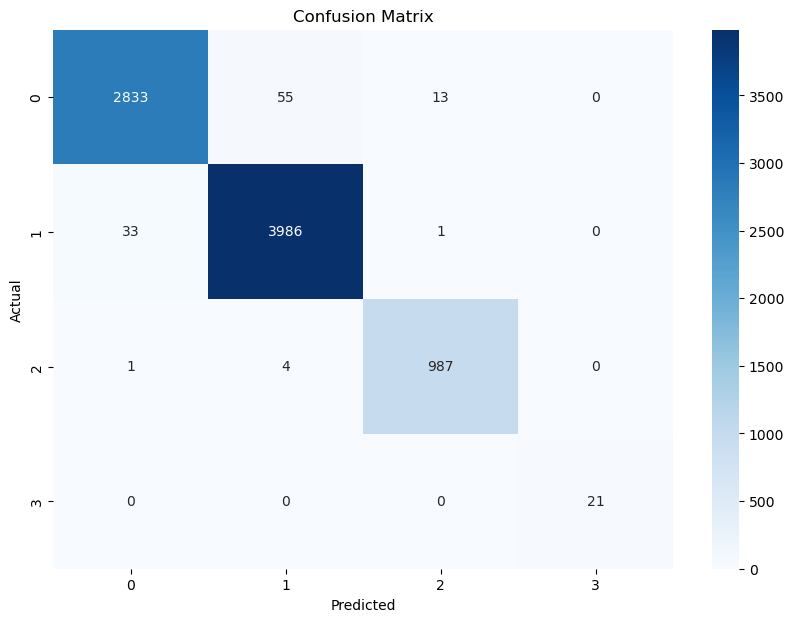

Size of the dataset:  38905
The range of the conductor: [200000, 210000]
Epoch [1/60], Loss: 1.0687, Train Accuracy: 0.5081, Test Accuracy: 0.4983
Epoch [2/60], Loss: 1.0106, Train Accuracy: 0.5081, Test Accuracy: 0.4983
Epoch [3/60], Loss: 0.9928, Train Accuracy: 0.5120, Test Accuracy: 0.5006
Epoch [4/60], Loss: 0.9433, Train Accuracy: 0.7192, Test Accuracy: 0.7086
Epoch [5/60], Loss: 0.8598, Train Accuracy: 0.6275, Test Accuracy: 0.6177
Epoch [6/60], Loss: 0.7283, Train Accuracy: 0.7856, Test Accuracy: 0.7858
Epoch [7/60], Loss: 0.5859, Train Accuracy: 0.8587, Test Accuracy: 0.8495
Epoch [8/60], Loss: 0.5109, Train Accuracy: 0.8720, Test Accuracy: 0.8654
Epoch [9/60], Loss: 0.4065, Train Accuracy: 0.9076, Test Accuracy: 0.8992
Epoch [10/60], Loss: 0.3230, Train Accuracy: 0.9266, Test Accuracy: 0.9195
Epoch [11/60], Loss: 0.3063, Train Accuracy: 0.9333, Test Accuracy: 0.9257
Epoch [12/60], Loss: 0.2677, Train Accuracy: 0.9196, Test Accuracy: 0.9115
Epoch [13/60], Loss: 0.2482, Train A

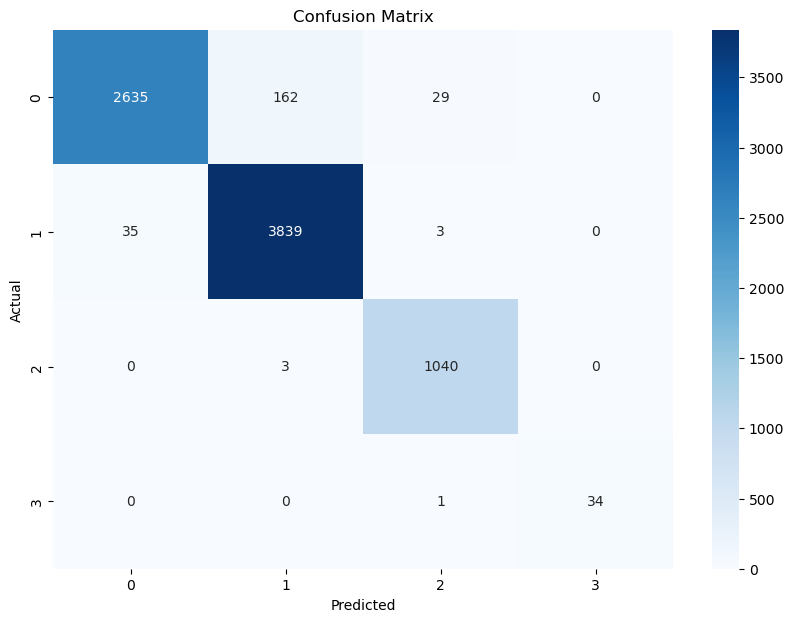

Size of the dataset:  36742
The range of the conductor: [300000, 310000]
Epoch [1/60], Loss: 1.0862, Train Accuracy: 0.5000, Test Accuracy: 0.5003
Epoch [2/60], Loss: 1.0128, Train Accuracy: 0.5000, Test Accuracy: 0.5003
Epoch [3/60], Loss: 0.9338, Train Accuracy: 0.6366, Test Accuracy: 0.6318
Epoch [4/60], Loss: 0.7937, Train Accuracy: 0.7503, Test Accuracy: 0.7419
Epoch [5/60], Loss: 0.6277, Train Accuracy: 0.8316, Test Accuracy: 0.8209
Epoch [6/60], Loss: 0.4901, Train Accuracy: 0.8833, Test Accuracy: 0.8715
Epoch [7/60], Loss: 0.4213, Train Accuracy: 0.8745, Test Accuracy: 0.8654
Epoch [8/60], Loss: 0.3850, Train Accuracy: 0.8850, Test Accuracy: 0.8781
Epoch [9/60], Loss: 0.3340, Train Accuracy: 0.9122, Test Accuracy: 0.9068
Epoch [10/60], Loss: 0.3076, Train Accuracy: 0.9227, Test Accuracy: 0.9145
Epoch [11/60], Loss: 0.2789, Train Accuracy: 0.9212, Test Accuracy: 0.9139
Epoch [12/60], Loss: 0.2555, Train Accuracy: 0.9295, Test Accuracy: 0.9207
Epoch [13/60], Loss: 0.2359, Train A

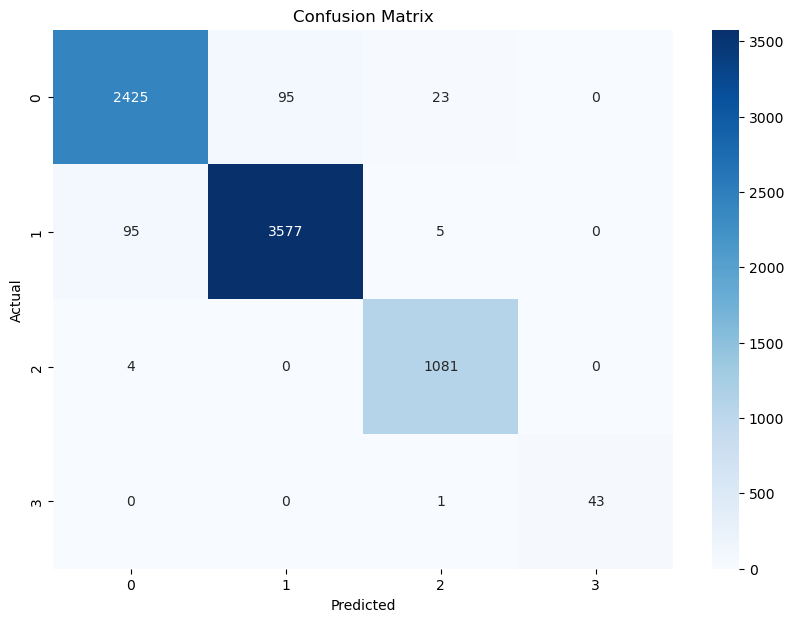

In [19]:
header = pd.read_csv('ECQ6_DF_ap.csv', nrows=0).columns
#rows = [[1168364, 1205106]]
rows = [[0, 36838], [402856, 442523],[791985, 830890],[1168364, 1205106]]
#rows = [0, 300000, 600000, 900000, 1200000]
#NROWS = 30000
batch_size = 3000
max_epochs = 60
feature_columns = PRIME_COLUMNS
saliency_value_list = []
test_accuracy_list = []
conductor_min_list = []
conductor_max_list = []

perm = np.random.permutation(1229)

for i in range(len(rows)):
    NROWS = rows[i][1] - rows[i][0]
    print('Size of the dataset: ', NROWS)
    DF_ap = pd.read_csv('ECQ6_DF_ap.csv', skiprows=rows[i][0]+1, nrows=NROWS, low_memory=False, header=None, names=header)
    conductor_min = i*100000
    conductor_max = i*100000 + 10000
    print('The range of the conductor: [{}, {}]'.format(conductor_min, conductor_max))
   
    # Extract feature columns and label
    X = DF_ap[feature_columns].values  # feature_columns are your input features   
    half = 1229 // 2
    X = np.concatenate([X[:,half:], X[:,:half]],axis=1)
    #blocks = np.array_split(X, 5, axis=1)
    #np.random.shuffle(blocks)
    #X = X[:,perm]
    #X = np.concatenate(blocks, axis=1)
    y = DF_ap['order_of_vanishing'].values  # This is your label
    del DF_ap
    gc.collect()

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # Scale the data (optional but recommended for neural networks)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data for CNN (batch_size, channels, sequence_length)
    X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
    X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

    # Convert data to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    class CNN(nn.Module):
        def __init__(self, num_classes):
            super(CNN, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
            self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
            self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
            self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

            # Dummy input to calculate flattened_size
            dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
            self.flattened_size = self._get_flattened_size(dummy_input)

            self.fc1 = nn.Linear(self.flattened_size, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

            self.dropout = nn.Dropout(0.5)

        def _get_flattened_size(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
            return x.view(1, -1).size(1)  # Flatten and get size
        
        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

            x = x.view(x.size(0), -1)  # Flatten
            x = self.dropout(x)  # Apply dropout
            x = torch.relu(self.fc1(x))  # Fully connected layer
            x = torch.relu(self.fc2(x))
            x = self.fc3(x)  # Output layer
            return x

    # Initialize model, loss function, and optimizer
    num_classes = len(set(y))
    model = CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Lists to store accuracy values
    train_accuracies = []
    test_accuracies = []

    # Training the model
    epochs = max_epochs
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        with torch.no_grad():
            # Train accuracy
            train_outputs = model(X_train)
            train_accuracy = calculate_accuracy(y_train, train_outputs)
            train_accuracies.append(train_accuracy)

            # Test accuracy
            test_outputs = model(X_test)
            test_accuracy = calculate_accuracy(y_test, test_outputs)
            test_accuracies.append(test_accuracy)

        # Print every 10 epochs
        if (epoch + 1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
                  f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

    test_accuracy_list.append(test_accuracies)
    #torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')
    
    # Confusion matrix
    _, y_predicted = torch.max(test_outputs, 1)
    cm = confusion_matrix(y_test.to('cpu'), y_predicted.to('cpu'))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y), yticklabels=set(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Saliency Map Calculation
    model.eval()  # Set the model to evaluation mode

    # Get a single sample from the test set for saliency calculation
    input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

    # Forward pass
    output = model(input_data)
    _, predicted_class = torch.max(output, 1)  # Get the predicted class index

    model.zero_grad()
    
    # Create a one-hot encoding of the predicted classes (this is a binary mask)
    one_hot = torch.zeros_like(output)
    one_hot[torch.arange(output.size(0)), predicted_class] = 1
    
    # Perform a single backward pass for the entire batch
    output.backward(gradient=one_hot, retain_graph=True)
    
    # The gradients for input_data will now be populated for the entire batch
    saliency = input_data.grad  # Saliency map for each sample
        
    # Average the saliency across the training set
    saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()
    
    saliency_value_list.append(saliency)

### Accuracy curve and saliency maps

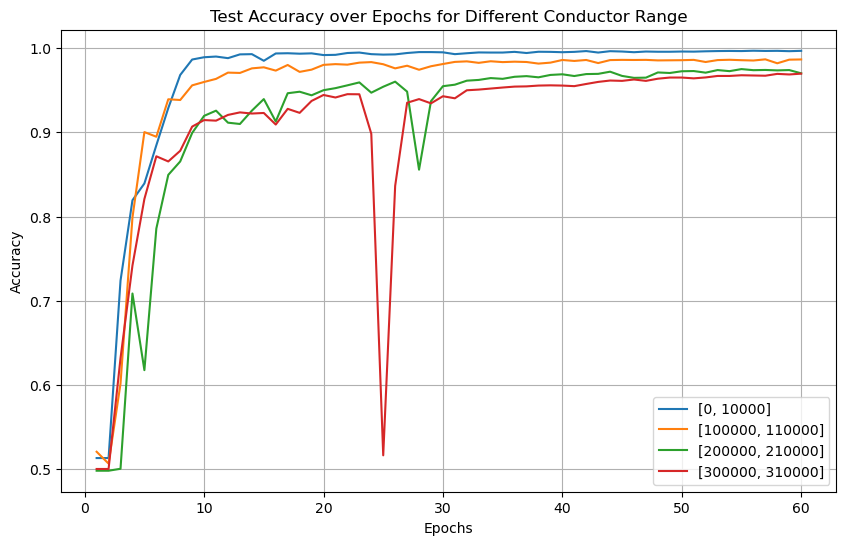

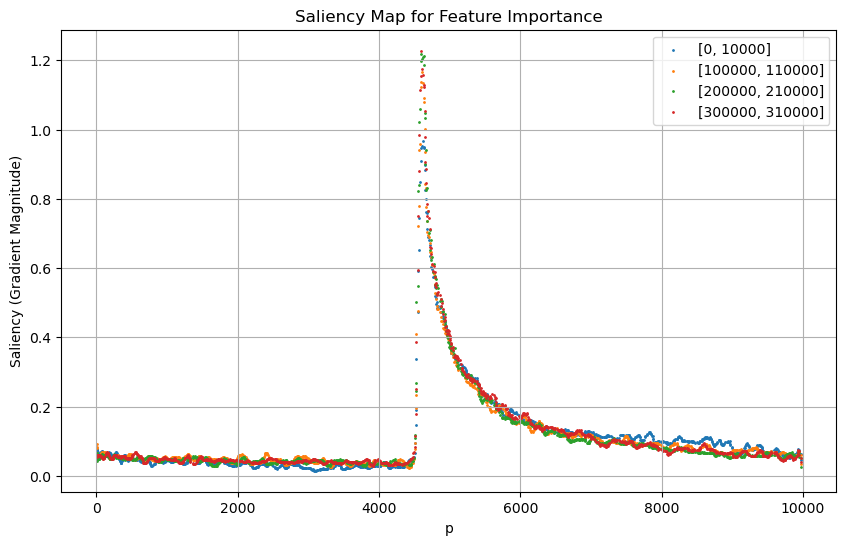

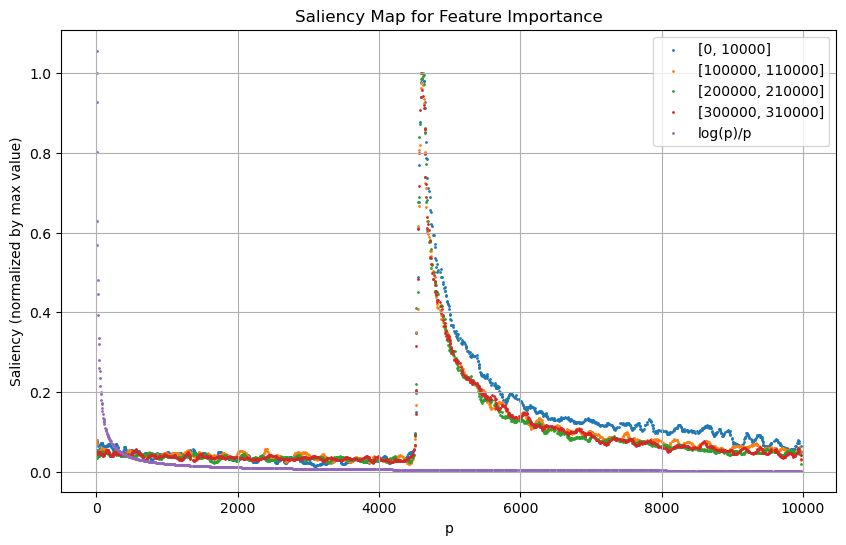

In [20]:
# Plotting train and test accuracy
plt.figure(figsize=(10, 6))
for i in range(len(rows)):
    plt.plot(range(1, epochs+1), test_accuracy_list[i], label=f'[{i*100000}, {i*100000+10000}]')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
for i in range(len(rows)):    
    plt.scatter(prime_numbers, saliency_value_list[i], label=f'[{i*100000}, {i*100000+10000}]', s=1)
#plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(10000)), label='log(p)/p', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (Gradient Magnitude)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
for i in range(len(rows)):    
    plt.scatter(prime_numbers, saliency_value_list[i]/np.max(saliency_value_list[i]), label=f'[{i*100000}, {i*100000+10000}]', s=1)
plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(2)/2), label='log(p)/p', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

### Class-based saliency maps and murmuration of saliency in low conductor range

In [25]:
header = pd.read_csv('ECQ6_DF_ap.csv', nrows=0).columns
rows = [[0, 36838]]
#rows = [[0, 36838], [402856, 442523],[791985, 830890],[1168364, 1205106]]
#rows = [0, 300000, 600000, 900000, 1200000]
#NROWS = 30000
batch_size = 3000
max_epochs = 30
feature_columns = PRIME_COLUMNS
saliency_value_list = []
class_saliency_list = []
test_accuracy_list = []
conductor_min_list = []
conductor_max_list = []

for i in range(len(rows)):
    NROWS = rows[i][1] - rows[i][0]
    print('Size of the dataset: ', NROWS)
    DF_ap = pd.read_csv('ECQ6_DF_ap.csv', skiprows=rows[i][0]+1, nrows=NROWS, low_memory=False, header=None, names=header)
    conductor_min = i*100000
    conductor_max = i*100000 + 10000
    print('The range of the conductor: [{}, {}]'.format(conductor_min, conductor_max))
   
    # Extract feature columns and label
    X = DF_ap[feature_columns].values  # feature_columns are your input features
    y = DF_ap['order_of_vanishing'].values  # This is your label
    del DF_ap
    gc.collect()

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # Scale the data (optional but recommended for neural networks)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data for CNN (batch_size, channels, sequence_length)
    X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
    X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

    # Convert data to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    class CNN(nn.Module):
        def __init__(self, num_classes):
            super(CNN, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
            self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
            self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
            self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

            # Dummy input to calculate flattened_size
            dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
            self.flattened_size = self._get_flattened_size(dummy_input)

            self.fc1 = nn.Linear(self.flattened_size, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

            self.dropout = nn.Dropout(0.5)

        def _get_flattened_size(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
            return x.view(1, -1).size(1)  # Flatten and get size
        
        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

            x = x.view(x.size(0), -1)  # Flatten
            x = self.dropout(x)  # Apply dropout
            x = torch.relu(self.fc1(x))  # Fully connected layer
            x = torch.relu(self.fc2(x))
            x = self.fc3(x)  # Output layer
            return x

    # Initialize model, loss function, and optimizer
    num_classes = len(set(y))
    model = CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Lists to store accuracy values
    train_accuracies = []
    test_accuracies = []

    # Training the model
    epochs = max_epochs
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        test_accuracy_steps = []
        step = 0
        for inputs, labels in train_loader:
            # Record the test accuracy in each step
            model.eval()
            with torch.no_grad():
                test_outputs = model(X_test)
                test_accuracy = calculate_accuracy(y_test, test_outputs)
                test_accuracy_steps.append(test_accuracy)
            
            torch.save(model.state_dict(), f'Conductor_models/{conductor_min}_{conductor_max}/{epoch}_{step}.pth')
            
            model.train()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            step += 1
            
        # Test accuracy of each epoch
        test_accuracy_list.append(test_accuracy_steps)
        model.eval()
        with torch.no_grad():
            # Train accuracy
            train_outputs = model(X_train)
            train_accuracy = calculate_accuracy(y_train, train_outputs)
            train_accuracies.append(train_accuracy)

        # Print every 10 epochs
        if (epoch + 1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
                  f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

        #torch.save(model.state_dict(), f'Conductor_models/{epoch}.pth')
        
    test_accuracy_list.append(test_accuracy_steps)
    with open('test_accuracy_list.pkl', 'wb') as file:
        pickle.dump(test_accuracy_list, file)
    #torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')

Size of the dataset:  38905
The range of the conductor: [200000, 210000]
Epoch [1/30], Loss: 1.0772, Train Accuracy: 0.5062, Test Accuracy: 0.5058
Epoch [2/30], Loss: 1.0054, Train Accuracy: 0.5062, Test Accuracy: 0.5058
Epoch [3/30], Loss: 0.9710, Train Accuracy: 0.6895, Test Accuracy: 0.7342
Epoch [4/30], Loss: 0.8877, Train Accuracy: 0.6616, Test Accuracy: 0.6950
Epoch [5/30], Loss: 0.7420, Train Accuracy: 0.7597, Test Accuracy: 0.7561
Epoch [6/30], Loss: 0.5823, Train Accuracy: 0.8051, Test Accuracy: 0.8032
Epoch [7/30], Loss: 0.4681, Train Accuracy: 0.8920, Test Accuracy: 0.8892
Epoch [8/30], Loss: 0.3813, Train Accuracy: 0.9276, Test Accuracy: 0.8977
Epoch [9/30], Loss: 0.2963, Train Accuracy: 0.9369, Test Accuracy: 0.9230
Epoch [10/30], Loss: 0.2644, Train Accuracy: 0.9370, Test Accuracy: 0.9280
Epoch [11/30], Loss: 0.2394, Train Accuracy: 0.9080, Test Accuracy: 0.9309
Epoch [12/30], Loss: 0.2315, Train Accuracy: 0.9480, Test Accuracy: 0.9444
Epoch [13/30], Loss: 0.2070, Train A

In [26]:
prime_numbers = [float(num) for num in feature_columns]

# Get a single sample from the test set for saliency calculation
input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

for epoch in range(30):
    print(f'Epoch: {epoch}')
    for step in range(10):      
        model = CNN(4).to(device)
        model.load_state_dict(torch.load(f'Conductor_models/{conductor_min}_{conductor_max}/{epoch}_{step}.pth', weights_only=True))

        # Saliency Map Calculation
        model.eval()  # Set the model to evaluation mode

        # Get a single sample from the test set for saliency calculation
        input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)
        
        # Forward pass
        output = model(input_data)
        _, predicted_class = torch.max(output, 1)  # Get the predicted class index

        # Compute the gradients of the predicted class with respect to the input
        #saliency = torch.zeros_like(input_data)  # Placeholder for saliency values
        class_saliency = [[] for _ in range(num_classes)]

        model.zero_grad()
        
        # Create a one-hot encoding of the predicted classes (this is a binary mask)
        one_hot = torch.zeros_like(output)
        one_hot[torch.arange(output.size(0)), predicted_class] = 1
        
        # Perform a single backward pass for the entire batch
        output.backward(gradient=one_hot, retain_graph=True)
        
        # The gradients for input_data will now be populated for the entire batch
        saliency = input_data.grad  # Saliency map for each sample
        for i in range(output.size(0)):
            class_saliency[predicted_class[i].item()].append(saliency[i])

        # Plotting
        plt.figure(figsize=(10, 6))
        for order in range(len(class_saliency)):
            try:
                saliency_y = torch.stack(class_saliency[order]).mean(dim=0).squeeze().cpu().numpy()
                plt.scatter(prime_numbers, saliency_y/(np.max(np.abs(saliency_y))), label=f'{order}', c=f'C{order}', s=1)
            except:
                pass
        #plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(2)/2), label='log(p)/p', s=1)
        plt.title(f'Saliency Map for Feature Importance (Conductor range: [{conductor_min}, {conductor_max}])')
        plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
        plt.xlabel('p')  # Label for y-axis
        plt.ylim(-1, 1)
        plt.legend()
        plt.grid(True)
        plt.text(0.75, 0.10, f'Epoch {epoch}, Step {step}, Accuracy: {test_accuracy_list[epoch][step]:.4f} ', ha='center', va='center', 
                 fontsize=12, color='black', transform=plt.gca().transAxes, fontweight='bold')
        plt.savefig(f"Saliency_plots/{epoch}_{step}.pdf", dpi=300, bbox_inches='tight')
        plt.close()

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29


## Log(p)/sqrt(p)

Size of the dataset:  36838
The range of the conductor: [0, 10000]
Epoch [1/100], Loss: 1.0006, Train Accuracy: 0.5180, Test Accuracy: 0.5209
Epoch [2/100], Loss: 0.8616, Train Accuracy: 0.5180, Test Accuracy: 0.5209
Epoch [3/100], Loss: 0.8286, Train Accuracy: 0.8920, Test Accuracy: 0.8910
Epoch [4/100], Loss: 0.7093, Train Accuracy: 0.8829, Test Accuracy: 0.8875
Epoch [5/100], Loss: 0.4761, Train Accuracy: 0.8886, Test Accuracy: 0.8853
Epoch [6/100], Loss: 0.3188, Train Accuracy: 0.9168, Test Accuracy: 0.9146
Epoch [7/100], Loss: 0.2034, Train Accuracy: 0.9399, Test Accuracy: 0.9411
Epoch [8/100], Loss: 0.1137, Train Accuracy: 0.9895, Test Accuracy: 0.9872
Epoch [9/100], Loss: 0.0704, Train Accuracy: 0.9921, Test Accuracy: 0.9909
Epoch [10/100], Loss: 0.0571, Train Accuracy: 0.9915, Test Accuracy: 0.9900
Epoch [11/100], Loss: 0.0493, Train Accuracy: 0.9941, Test Accuracy: 0.9920
Epoch [12/100], Loss: 0.0414, Train Accuracy: 0.9950, Test Accuracy: 0.9929
Epoch [13/100], Loss: 0.0360, 

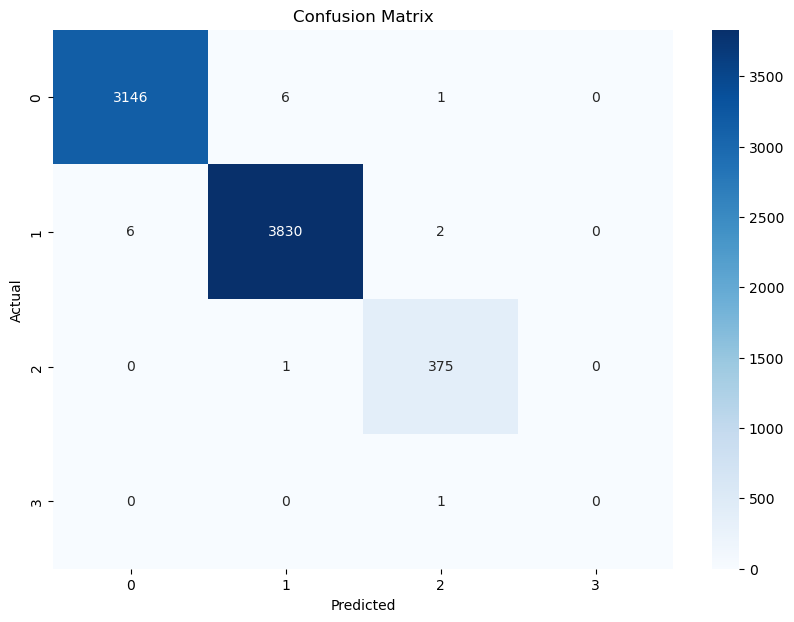

Size of the dataset:  39667
The range of the conductor: [100000, 110000]
Epoch [1/100], Loss: 1.0483, Train Accuracy: 0.4997, Test Accuracy: 0.5054
Epoch [2/100], Loss: 0.9851, Train Accuracy: 0.4997, Test Accuracy: 0.5054
Epoch [3/100], Loss: 0.9169, Train Accuracy: 0.7843, Test Accuracy: 0.7835
Epoch [4/100], Loss: 0.7479, Train Accuracy: 0.7918, Test Accuracy: 0.7923
Epoch [5/100], Loss: 0.5365, Train Accuracy: 0.8370, Test Accuracy: 0.8301
Epoch [6/100], Loss: 0.3718, Train Accuracy: 0.8958, Test Accuracy: 0.8851
Epoch [7/100], Loss: 0.2955, Train Accuracy: 0.9233, Test Accuracy: 0.9142
Epoch [8/100], Loss: 0.2442, Train Accuracy: 0.9510, Test Accuracy: 0.9490
Epoch [9/100], Loss: 0.2017, Train Accuracy: 0.9515, Test Accuracy: 0.9482
Epoch [10/100], Loss: 0.1816, Train Accuracy: 0.9538, Test Accuracy: 0.9503
Epoch [11/100], Loss: 0.1695, Train Accuracy: 0.9562, Test Accuracy: 0.9510
Epoch [12/100], Loss: 0.1781, Train Accuracy: 0.9157, Test Accuracy: 0.9077
Epoch [13/100], Loss: 0.

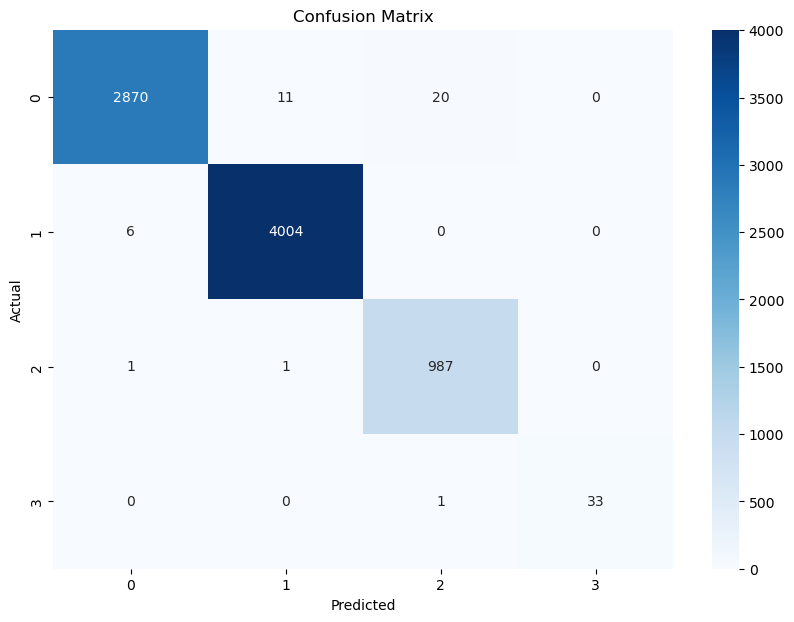

Size of the dataset:  38905
The range of the conductor: [200000, 210000]
Epoch [1/100], Loss: 1.0910, Train Accuracy: 0.5072, Test Accuracy: 0.5021
Epoch [2/100], Loss: 1.0052, Train Accuracy: 0.5072, Test Accuracy: 0.5021
Epoch [3/100], Loss: 0.9766, Train Accuracy: 0.5123, Test Accuracy: 0.5062
Epoch [4/100], Loss: 0.8678, Train Accuracy: 0.7632, Test Accuracy: 0.7534
Epoch [5/100], Loss: 0.6762, Train Accuracy: 0.7702, Test Accuracy: 0.7631
Epoch [6/100], Loss: 0.4868, Train Accuracy: 0.8679, Test Accuracy: 0.8627
Epoch [7/100], Loss: 0.3494, Train Accuracy: 0.9358, Test Accuracy: 0.9350
Epoch [8/100], Loss: 0.2739, Train Accuracy: 0.9421, Test Accuracy: 0.9419
Epoch [9/100], Loss: 0.2244, Train Accuracy: 0.9437, Test Accuracy: 0.9447
Epoch [10/100], Loss: 0.2031, Train Accuracy: 0.9493, Test Accuracy: 0.9503
Epoch [11/100], Loss: 0.1801, Train Accuracy: 0.9537, Test Accuracy: 0.9532
Epoch [12/100], Loss: 0.1589, Train Accuracy: 0.9533, Test Accuracy: 0.9531
Epoch [13/100], Loss: 0.

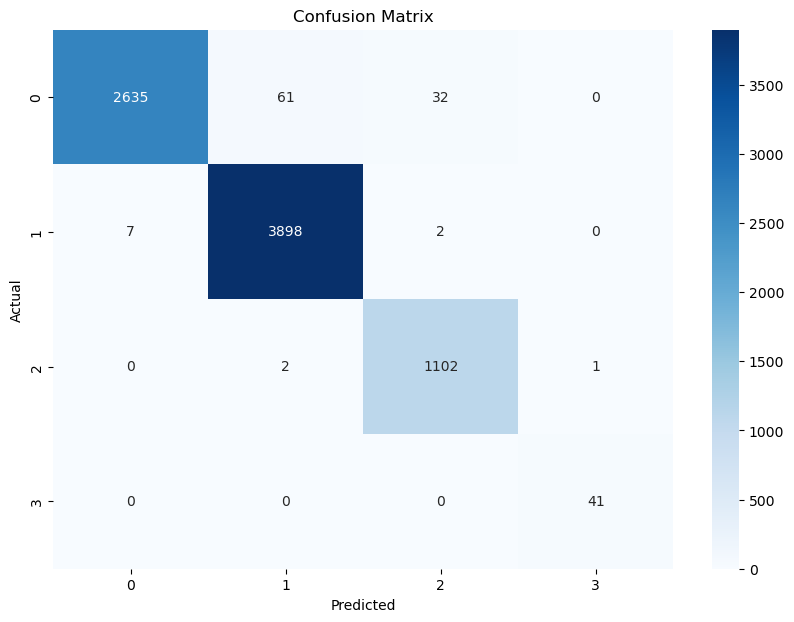

Size of the dataset:  36742
The range of the conductor: [300000, 310000]
Epoch [1/100], Loss: 1.0845, Train Accuracy: 0.5001, Test Accuracy: 0.4999
Epoch [2/100], Loss: 1.0143, Train Accuracy: 0.5510, Test Accuracy: 0.5518
Epoch [3/100], Loss: 0.9610, Train Accuracy: 0.6419, Test Accuracy: 0.6352
Epoch [4/100], Loss: 0.8486, Train Accuracy: 0.6599, Test Accuracy: 0.6548
Epoch [5/100], Loss: 0.6941, Train Accuracy: 0.6982, Test Accuracy: 0.6877
Epoch [6/100], Loss: 0.5876, Train Accuracy: 0.8358, Test Accuracy: 0.8341
Epoch [7/100], Loss: 0.4624, Train Accuracy: 0.8940, Test Accuracy: 0.8967
Epoch [8/100], Loss: 0.3706, Train Accuracy: 0.9143, Test Accuracy: 0.9151
Epoch [9/100], Loss: 0.3106, Train Accuracy: 0.9201, Test Accuracy: 0.9212
Epoch [10/100], Loss: 0.2796, Train Accuracy: 0.9201, Test Accuracy: 0.9205
Epoch [11/100], Loss: 0.2572, Train Accuracy: 0.9134, Test Accuracy: 0.9122
Epoch [12/100], Loss: 0.2280, Train Accuracy: 0.9328, Test Accuracy: 0.9316
Epoch [13/100], Loss: 0.

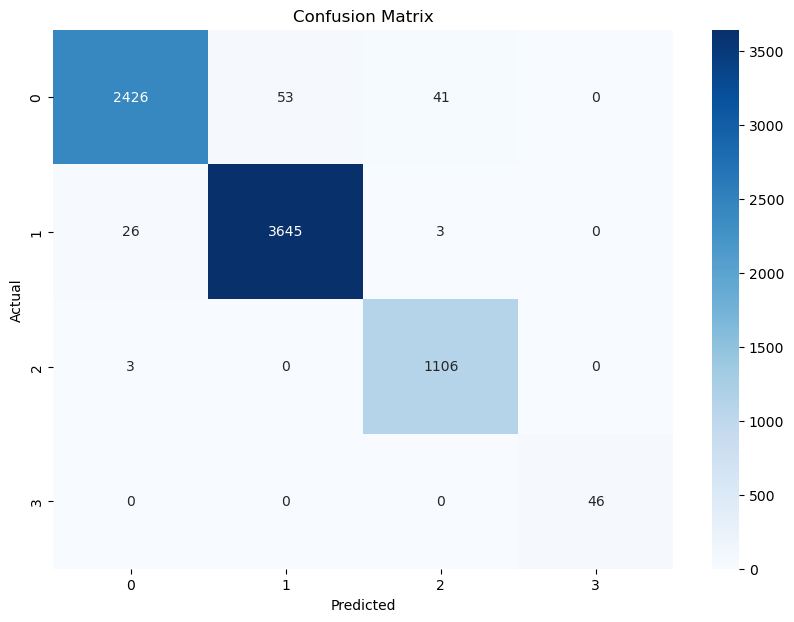

In [25]:
header = pd.read_csv('ECQ6_DF_ap.csv', nrows=0).columns
#rows = [[0, 36838]]
rows = [[0, 36838], [402856, 442523],[791985, 830890],[1168364, 1205106]]
#rows = [0, 300000, 600000, 900000, 1200000]
#NROWS = 30000
batch_size = 3000
max_epochs = 100
feature_columns = PRIME_COLUMNS
saliency_value_list = []
test_accuracy_list = []
conductor_min_list = []
conductor_max_list = []

perm = np.random.permutation(1229)

for i in range(len(rows)):
    NROWS = rows[i][1] - rows[i][0]
    print('Size of the dataset: ', NROWS)
    DF_ap = pd.read_csv('ECQ6_DF_ap.csv', skiprows=rows[i][0]+1, nrows=NROWS, low_memory=False, header=None, names=header)
    conductor_min = i*100000
    conductor_max = i*100000 + 10000
    print('The range of the conductor: [{}, {}]'.format(conductor_min, conductor_max))
   
    # Extract feature columns and label
    X = DF_ap[feature_columns].values  # feature_columns are your input features   
    y = DF_ap['order_of_vanishing'].values  # This is your label
    del DF_ap
    gc.collect()

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # Scale the data (optional but recommended for neural networks)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data for CNN (batch_size, channels, sequence_length)
    X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
    X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

    # Convert data to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    class CNN(nn.Module):
        def __init__(self, num_classes):
            super(CNN, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
            self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
            self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
            self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

            # Dummy input to calculate flattened_size
            dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
            self.flattened_size = self._get_flattened_size(dummy_input)

            self.fc1 = nn.Linear(self.flattened_size, 128)
            self.fc2 = nn.Linear(128, 128)
            self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

            self.dropout = nn.Dropout(0.5)

        def _get_flattened_size(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
            return x.view(1, -1).size(1)  # Flatten and get size
        
        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
            x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
            x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

            x = x.view(x.size(0), -1)  # Flatten
            x = self.dropout(x)  # Apply dropout
            x = torch.relu(self.fc1(x))  # Fully connected layer
            x = torch.relu(self.fc2(x))
            x = self.fc3(x)  # Output layer
            return x

    # Initialize model, loss function, and optimizer
    num_classes = len(set(y))
    model = CNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()  # Loss function for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Lists to store accuracy values
    train_accuracies = []
    test_accuracies = []

    # Training the model
    epochs = max_epochs
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        with torch.no_grad():
            # Train accuracy
            train_outputs = model(X_train)
            train_accuracy = calculate_accuracy(y_train, train_outputs)
            train_accuracies.append(train_accuracy)

            # Test accuracy
            test_outputs = model(X_test)
            test_accuracy = calculate_accuracy(y_test, test_outputs)
            test_accuracies.append(test_accuracy)

        # Print every 10 epochs
        if (epoch + 1) % 1 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
                  f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

    test_accuracy_list.append(test_accuracies)
    #torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')
    
    # Confusion matrix
    _, y_predicted = torch.max(test_outputs, 1)
    cm = confusion_matrix(y_test.to('cpu'), y_predicted.to('cpu'))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y), yticklabels=set(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Saliency Map Calculation
    model.eval()  # Set the model to evaluation mode

    # Get a single sample from the test set for saliency calculation
    input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

    # Forward pass
    output = model(input_data)
    _, predicted_class = torch.max(output, 1)  # Get the predicted class index

    model.zero_grad()
    
    # Create a one-hot encoding of the predicted classes (this is a binary mask)
    one_hot = torch.zeros_like(output)
    one_hot[torch.arange(output.size(0)), predicted_class] = 1
    
    # Perform a single backward pass for the entire batch
    output.backward(gradient=one_hot, retain_graph=True)
    
    # The gradients for input_data will now be populated for the entire batch
    saliency = input_data.grad  # Saliency map for each sample
        
    # Average the saliency across the training set
    saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()
    
    saliency_value_list.append(saliency)

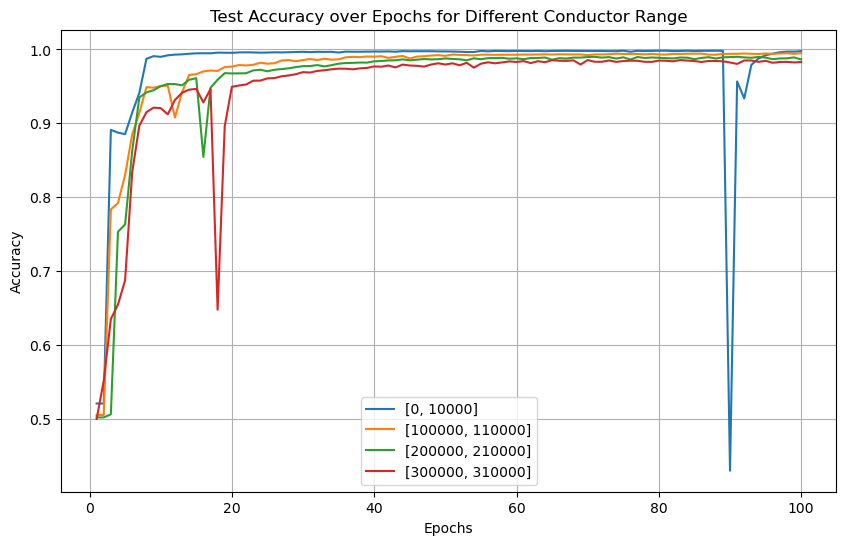

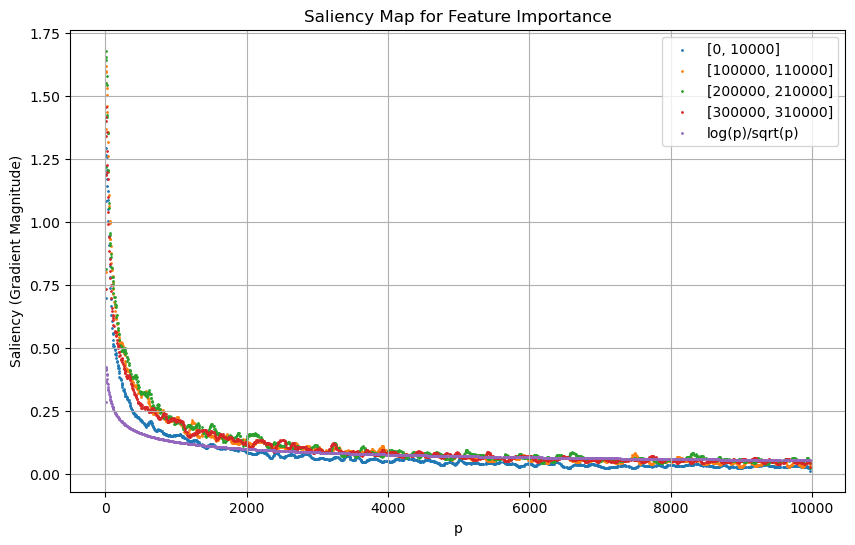

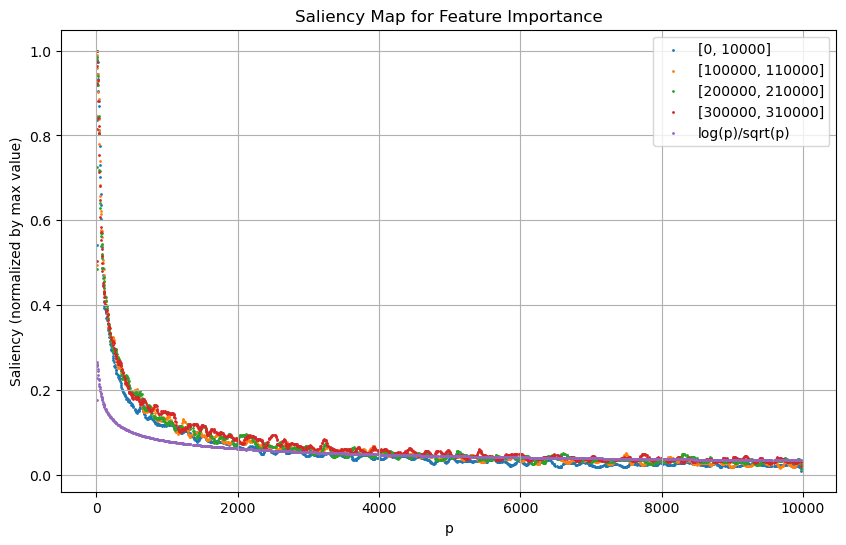

In [35]:
# Plotting train and test accuracy
plt.figure(figsize=(10, 6))
for i in range(len(rows)):
    plt.plot(range(1, epochs+1), test_accuracy_list[i], label=f'[{i*100000}, {i*100000+10000}]')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
for i in range(len(rows)):    
    plt.scatter(prime_numbers, saliency_value_list[i], label=f'[{i*100000}, {i*100000+10000}]', s=1)
#plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(10000)), label='log(p)/p', s=1)
plt.scatter(prime_numbers, np.log(prime_numbers) / np.sqrt(prime_numbers) / (np.log(2)/2)/5, label='log(p)/sqrt(p)', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (Gradient Magnitude)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
for i in range(len(rows)):    
    plt.scatter(prime_numbers, saliency_value_list[i]/np.max(saliency_value_list[i]), label=f'[{i*100000}, {i*100000+10000}]', s=1)
#plt.scatter(prime_numbers, np.log(prime_numbers) / np.sqrt(prime_numbers) / (np.log(2)/2), label='log(p)/sqrt(p)', s=1)
plt.scatter(prime_numbers, np.log(prime_numbers) / np.sqrt(prime_numbers) / (np.log(2)/2)/8, label='log(p)/sqrt(p)', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

## Relation between conductor and the number of a_ps needed for high accuracy

In [ ]:
import time

header = pd.read_csv('ECQ6_DF_ap.csv', nrows=0).columns
rows = [[0, 36838], [402856, 442523],[791985, 830890],[1168364, 1205106]]
#rows = [0, 300000, 600000, 900000, 1200000]
#NROWS = 30000
batch_size = 3000
feature_columns = PRIME_COLUMNS
#prime_range = range(15, 1229, 10)
#prime_range = range(15, 45, 10)
prime_range = range(5, 1229, 10)
test_accuracy_list = []
conductor_min_list = []
conductor_max_list = []

for i in range(len(rows)):
    NROWS = rows[i][1] - rows[i][0]
    print('Size of the dataset: ', NROWS)
    best_accuracies = []
    DF_ap = pd.read_csv('ECQ6_DF_ap.csv', skiprows=rows[i][0]+1, nrows=NROWS, low_memory=False, header=None, names=header)
    conductor_min = DF_ap['conductor'].min()
    conductor_max = DF_ap['conductor'].max()
    conductor_min_list.append(conductor_min)
    conductor_max_list.append(conductor_max)
    print('The range of the conductor: [{}, {}]'.format(conductor_min, conductor_max))

    for n_prime_used in prime_range:
        start_time = time.time()
        # Extract feature columns and label
        X = DF_ap[feature_columns[:n_prime_used]].values  # feature_columns are your input features
        y = DF_ap['order_of_vanishing'].values  # This is your label
    
        # Split data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1042)
    
        # Scale the data (optional but recommended for neural networks)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
        # Reshape data for CNN (batch_size, channels, sequence_length)
        X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
        X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel
    
        # Convert data to PyTorch tensors
        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train = torch.tensor(y_train, dtype=torch.long).to(device)
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(device)
    
        train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
        class CNN(nn.Module):
            def __init__(self, num_classes):
                super(CNN, self).__init__()
                self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
                self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
                self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
                self.pool = nn.MaxPool1d(kernel_size=2, padding=1)
    
                # Dummy input to calculate flattened_size
                dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
                self.flattened_size = self._get_flattened_size(dummy_input)
    
                self.fc1 = nn.Linear(self.flattened_size, 128)
                self.fc2 = nn.Linear(128, 128)
                self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification
    
                self.dropout = nn.Dropout(0.5)

            def _get_flattened_size(self, x):
                x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
                x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
                x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
                return x.view(1, -1).size(1)  # Flatten and get size
            
            def forward(self, x):
                x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
                x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
                x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling
    
                x = x.view(x.size(0), -1)  # Flatten
                x = self.dropout(x)  # Apply dropout
                x = torch.relu(self.fc1(x))  # Fully connected layer
                x = torch.relu(self.fc2(x))
                x = self.fc3(x)  # Output layer
                return x
    
        # Initialize model, loss function, and optimizer
        num_classes = len(set(y))
        model = CNN(num_classes).to(device)
        criterion = nn.CrossEntropyLoss()  # Loss function for classification
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    
        # Training the model
        max_epochs = 400
        patience = 10  # Number of epochs to wait for improvement
        best_accuracy = 0
        epochs_no_improve = 0
        
        for epoch in range(max_epochs):
            model.train()
            running_loss = 0.0

            for inputs, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
  
            model.eval()
            with torch.no_grad():               
                # Test accuracy
                test_outputs = model(X_test)
                test_accuracy = calculate_accuracy(y_test, test_outputs)
                # Check for improvement
                if test_accuracy > best_accuracy:
                    best_accuracy = test_accuracy
                    epochs_no_improve = 0  # Reset counter
                else:
                    epochs_no_improve += 1

                # Early stopping condition
                if epochs_no_improve >= patience or epoch >= max_epochs:
                    break

        print(f"N prime used: {n_prime_used}, Epoch {epoch + 1}/{max_epochs}, Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}, Best Accuracy: {best_accuracy:.4f}, Train time: {time.time() - start_time:.2f}")            
        best_accuracies.append(best_accuracy)

    with open(f'test_accuracies/{10000*i}.txt', 'w') as file:
        for prime, accuracy in zip(prime_range, best_accuracies):
            file.write(f"{prime} {accuracy}\n")
        
    test_accuracy_list.append(best_accuracies)
        #torch.save(model.state_dict(), 'Conductor_models/row_{}_to_{}.pth'.format(rows[i], rows[i]+NROWS))
    
plt.figure(figsize=(10, 6))
for i in range(len(rows)):
    plt.plot(prime_range, test_accuracy_list[i], label='[{}, {}]'.format(conductor_min_list[i], conductor_max_list[i]))
plt.xlabel('Number of a_ps used')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over the number of a_ps used for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

Size of the dataset:  36838
The range of the conductor: [11, 10001]
N prime used: 5, Epoch 67/400, Loss: 0.6537, Test Accuracy: 0.6675, Best Accuracy: 0.6684, Train time: 31.82
N prime used: 15, Epoch 115/400, Loss: 0.3115, Test Accuracy: 0.8666, Best Accuracy: 0.8708, Train time: 48.66
N prime used: 25, Epoch 111/400, Loss: 0.1752, Test Accuracy: 0.9305, Best Accuracy: 0.9334, Train time: 47.32
N prime used: 35, Epoch 123/400, Loss: 0.0914, Test Accuracy: 0.9644, Best Accuracy: 0.9655, Train time: 52.04
N prime used: 45, Epoch 109/400, Loss: 0.0528, Test Accuracy: 0.9764, Best Accuracy: 0.9775, Train time: 53.30
N prime used: 55, Epoch 106/400, Loss: 0.0430, Test Accuracy: 0.9852, Best Accuracy: 0.9852, Train time: 46.82
N prime used: 65, Epoch 59/400, Loss: 0.0462, Test Accuracy: 0.9852, Best Accuracy: 0.9860, Train time: 26.31
N prime used: 75, Epoch 64/400, Loss: 0.0402, Test Accuracy: 0.9886, Best Accuracy: 0.9886, Train time: 28.53
N prime used: 85, Epoch 66/400, Loss: 0.0381, Te

In [6]:
header = pd.read_csv('ECQ6_DF_ap.csv', nrows=0).columns
rows = [[0, 36838], [402856, 442523],[791985, 830890],[1168364, 1205106]]
#rows = [0, 300000, 600000, 900000, 1200000]
#NROWS = 30000
batch_size = 3000
feature_columns = PRIME_COLUMNS
#prime_range = range(15, 1229, 10)
#prime_range = range(15, 45, 10)
prime_range = range(5, 1229, 10)
test_accuracy_list = []
conductor_min_list = []
conductor_max_list = []

for i in range(len(rows)):
    NROWS = rows[i][1] - rows[i][0]
    print('Size of the dataset: ', NROWS)

Size of the dataset:  36838
Size of the dataset:  39667
Size of the dataset:  38905
Size of the dataset:  36742


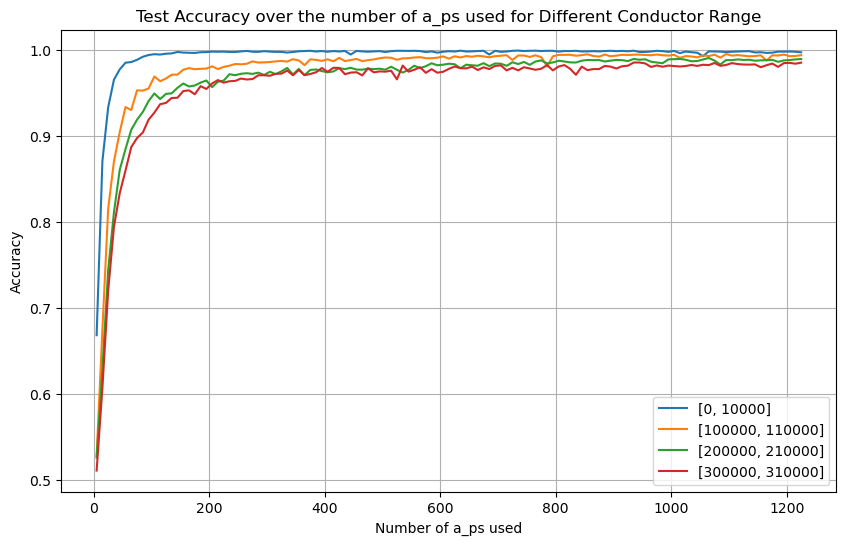

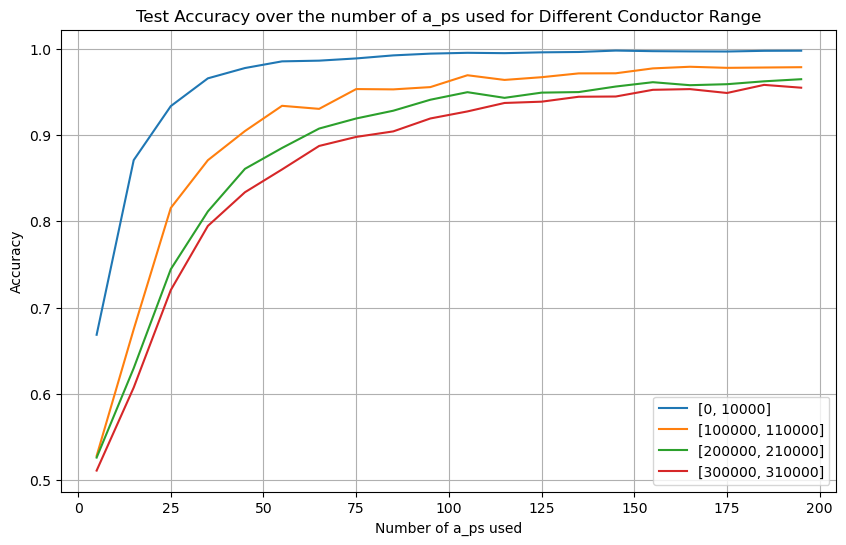

In [22]:
test_accuracy_list = []
for i in range(4):
    file_path = f'test_accuracies/{i*100000}.txt'
    data = np.loadtxt(file_path)
    
    primes = data[:, 0]
    test_accuracy = data[:, 1]
    test_accuracy_list.append(test_accuracy)

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(primes, test_accuracy_list[i], label=f'[{i*100000}, {i*100000+10000}]')
plt.xlabel('Number of a_ps used')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over the number of a_ps used for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(primes[:20], test_accuracy_list[i][:20], label=f'[{i*100000}, {i*100000+10000}]')
plt.xlabel('Number of a_ps used')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over the number of a_ps used for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

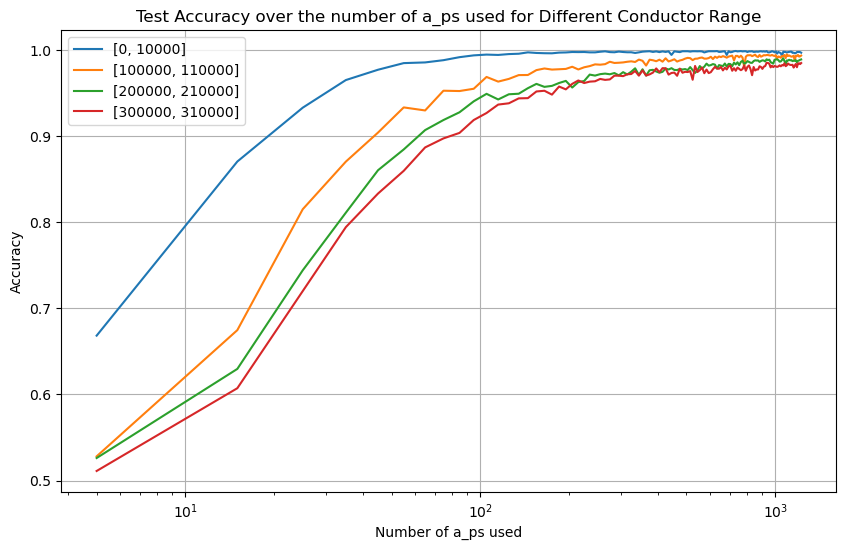

In [13]:
import numpy as np
import matplotlib.pyplot as plt
test_accuracy_list = []
for i in range(4):
    file_path = f'test_accuracies/{i*100000}.txt'
    data = np.loadtxt(file_path)
    
    primes = data[:, 0]
    test_accuracy = data[:, 1]
    test_accuracy_list.append(test_accuracy)

plt.figure(figsize=(10, 6))
for i in range(4):
    #plt.plot(np.log10(range(5, 1229, 10)), test_accuracy_list[i], label=f'[{i*100000}, {i*100000+10000}]')
    plt.plot(primes, test_accuracy_list[i], label=f'[{i*100000}, {i*100000+10000}]')
plt.xlabel('Number of a_ps used (log scale)')
plt.ylabel('Accuracy')
plt.xscale('log') 
plt.title('Test Accuracy over the number of a_ps used for Different Conductor Range')
plt.legend()
plt.grid(True)
plt.show()

## CNN on PRAT dataset

In [4]:
DF = pd.read_table('lfun_rat_ap.txt',delimiter=":",header='infer', low_memory=False)

In [5]:
DF = DF[DF['primitive'] == True]

In [6]:
DF_ap = build_ap_df(DF)
del DF
gc.collect()

20

In [ ]:
from matplotlib.ticker import ScalarFormatter
conductors = DF_ap['conductor'].to_numpy().astype(int)

plt.figure(figsize=(10, 6))

# Create a histogram with 20 bins
sns.histplot(conductors, bins=100)

plt.title('Distribution of Conductor')
plt.xlabel('Conductor')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.get_major_formatter().set_scientific(False)
plt.tight_layout()
plt.show()

In [7]:
from collections import Counter
import ast

def compute_instance_type_stats(dataframe, column_name, instance_types):
    # Flatten the lists in the column and create a Counter
    flattened = [item for sublist in dataframe[column_name].apply(ast.literal_eval) for item in list(set(sublist))]
    counts = Counter(flattened)

    # Print the count for each instance type
    for instance in instance_types:
        print(f"{instance}: {counts.get(instance, 0)}")

possible_instance_types = ['CMF', 'ECQ', 'Artin', 'ECNF', 'BMF', 'HMF', 'DIR', 'G2Q']

# Compute the statistics
compute_instance_type_stats(DF_ap, 'instance_types', possible_instance_types)

CMF: 9675
ECQ: 5860
Artin: 2557
ECNF: 113489
BMF: 81803
HMF: 31964
DIR: 274
G2Q: 62789


In [13]:
DF_train, DF_test = train_test_split(DF_ap, test_size=0.2, random_state=0)

In [11]:
compute_instance_type_stats(DF_train, 'instance_types', possible_instance_types)

CMF: 7670
ECQ: 4656
Artin: 2015
ECNF: 90862
BMF: 65442
HMF: 25649
DIR: 216
G2Q: 50233


In [12]:
# Check if test set is evenly distributed
compute_instance_type_stats(DF_test, 'instance_types', possible_instance_types)

CMF: 2005
ECQ: 1204
Artin: 542
ECNF: 22627
BMF: 16361
HMF: 6315
DIR: 58
G2Q: 12556


In [14]:
type_indices = {
    instance_type: DF_test['instance_types'].apply(ast.literal_eval).apply(lambda x: instance_type in x).values
    for instance_type in possible_instance_types
}

In [15]:
batch_size = 3000
feature_columns = PRIME_COLUMNS[:168]

# Extract feature columns and label
X_train = DF_train[feature_columns].values  # feature_columns are your input features
y_train = DF_train['order_of_vanishing'].values  # This is your label
X_test = DF_test[feature_columns].values  # feature_columns are your input features
y_test = DF_test['order_of_vanishing'].values  # This is your label

#del DF_train, DF_test, DF_ap
#gc.collect()

# Scale the data (optional but recommended for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN (batch_size, channels, sequence_length)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [16]:
max_epochs = 25
saliency_value_list = []
test_accuracy_list = []

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

        # Dummy input to calculate flattened_size
        dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
        self.flattened_size = self._get_flattened_size(dummy_input)

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

        self.dropout = nn.Dropout(0.5)

    def _get_flattened_size(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
        return x.view(1, -1).size(1)  # Flatten and get size
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)  # Apply dropout
        x = torch.relu(self.fc1(x))  # Fully connected layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer
        return x

# Initialize model, loss function, and optimizer
num_classes = len(set(y_test.numpy()))
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store accuracy values
train_accuracies = []
test_accuracies = []
test_accuracies_type = {instance_type : [] for instance_type in possible_instance_types}

model.eval()
with torch.no_grad():
    
    # Test accuracies for different types
    for instance_type in possible_instance_types:
        test_outputs = model(X_test[type_indices[instance_type]].to(device))
        test_accuracy = calculate_accuracy(y_test[type_indices[instance_type]].to(device), test_outputs)
        test_accuracies_type[instance_type].append(test_accuracy) 
        
# Training the model
epochs = max_epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    with torch.no_grad():
        # Train accuracy
        #train_outputs = model(X_train)
        #train_accuracy = calculate_accuracy(y_train, train_outputs)
        train_accuracy = calculate_accuracy(labels, outputs)
        train_accuracies.append(train_accuracy)

        # Test accuracy
        test_outputs = model(X_test.to(device))
        test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
        test_accuracies.append(test_accuracy)

        # Test accuracies for different types
        for instance_type in possible_instance_types:
            test_outputs = model(X_test[type_indices[instance_type]].to(device))
            test_accuracy = calculate_accuracy(y_test[type_indices[instance_type]].to(device), test_outputs)
            test_accuracies_type[instance_type].append(test_accuracy) 

    # Print every 10 epochs
    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

test_accuracy_list.append(test_accuracies)
#torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')

    
# Saliency Map Calculation
model.eval()  # Set the model to evaluation mode

# Get a single sample from the test set for saliency calculation
input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

# Forward pass
output = model(input_data.to(device))
_, predicted_class = torch.max(output, 1)  # Get the predicted class index

model.zero_grad()

# Create a one-hot encoding of the predicted classes (this is a binary mask)
one_hot = torch.zeros_like(output)
one_hot[torch.arange(output.size(0)), predicted_class] = 1

# Perform a single backward pass for the entire batch
output.backward(gradient=one_hot, retain_graph=True)

# The gradients for input_data will now be populated for the entire batch
saliency = input_data.grad  # Saliency map for each sample
    
# Average the saliency across the training set
saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()

saliency_value_list.append(saliency)

Epoch [1/25], Loss: 1.0152, Train Accuracy: 0.7641, Test Accuracy: 0.5880
Epoch [2/25], Loss: 0.3328, Train Accuracy: 0.9069, Test Accuracy: 0.9139
Epoch [3/25], Loss: 0.2155, Train Accuracy: 0.9302, Test Accuracy: 0.9359
Epoch [4/25], Loss: 0.1853, Train Accuracy: 0.9376, Test Accuracy: 0.9503
Epoch [5/25], Loss: 0.1714, Train Accuracy: 0.9413, Test Accuracy: 0.9517
Epoch [6/25], Loss: 0.1602, Train Accuracy: 0.9445, Test Accuracy: 0.9599
Epoch [7/25], Loss: 0.1527, Train Accuracy: 0.9350, Test Accuracy: 0.9544
Epoch [8/25], Loss: 0.1490, Train Accuracy: 0.9424, Test Accuracy: 0.9612
Epoch [9/25], Loss: 0.1443, Train Accuracy: 0.9418, Test Accuracy: 0.9657
Epoch [10/25], Loss: 0.1413, Train Accuracy: 0.9551, Test Accuracy: 0.9622
Epoch [11/25], Loss: 0.1376, Train Accuracy: 0.9466, Test Accuracy: 0.9613
Epoch [12/25], Loss: 0.1342, Train Accuracy: 0.9513, Test Accuracy: 0.9650
Epoch [13/25], Loss: 0.1388, Train Accuracy: 0.9540, Test Accuracy: 0.9688
Epoch [14/25], Loss: 0.1305, Train

In [17]:
saliency_type_dict = dict.fromkeys(possible_instance_types, None)
for instance_type in possible_instance_types:

    # Get a single sample from the test set for saliency calculation
    X_test_type = X_test[type_indices[instance_type]]
    input_data = X_test_type[torch.randperm(X_test_type.size(0))[:3000]].clone().detach().requires_grad_(True)
    
    # Forward pass
    output = model(input_data.to(device))
    _, predicted_class = torch.max(output, 1)  # Get the predicted class index
    
    model.zero_grad()
    
    # Create a one-hot encoding of the predicted classes (this is a binary mask)
    one_hot = torch.zeros_like(output)
    one_hot[torch.arange(output.size(0)), predicted_class] = 1
    
    # Perform a single backward pass for the entire batch
    output.backward(gradient=one_hot, retain_graph=True)
    
    # The gradients for input_data will now be populated for the entire batch
    saliency = input_data.grad  # Saliency map for each sample
        
    # Average the saliency across the training set
    saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()
    
    saliency_type_dict[instance_type] = saliency

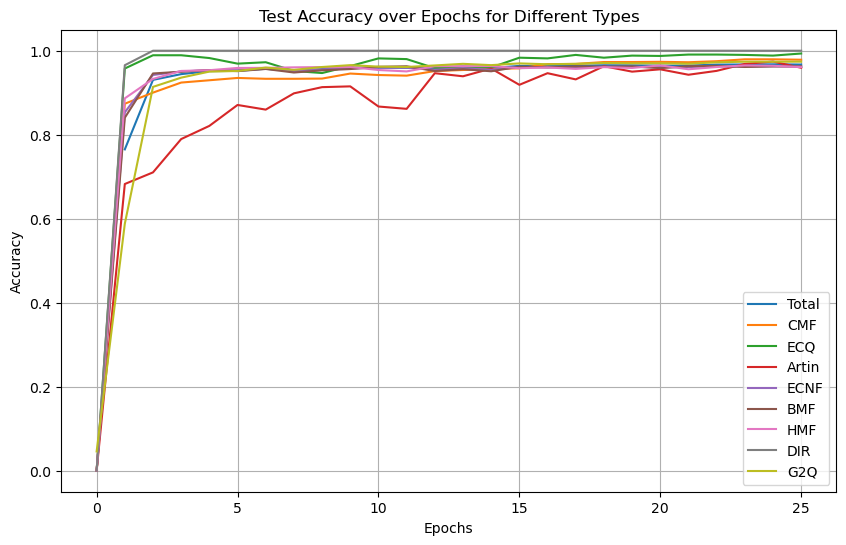

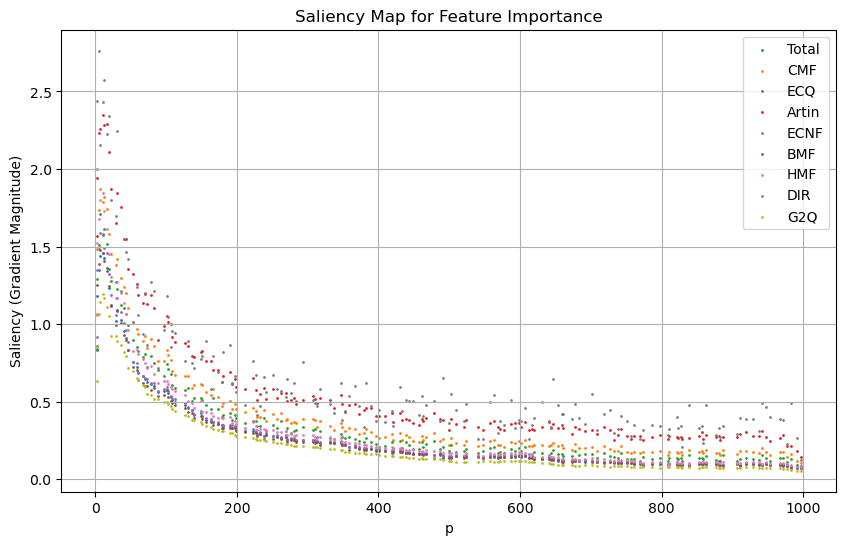

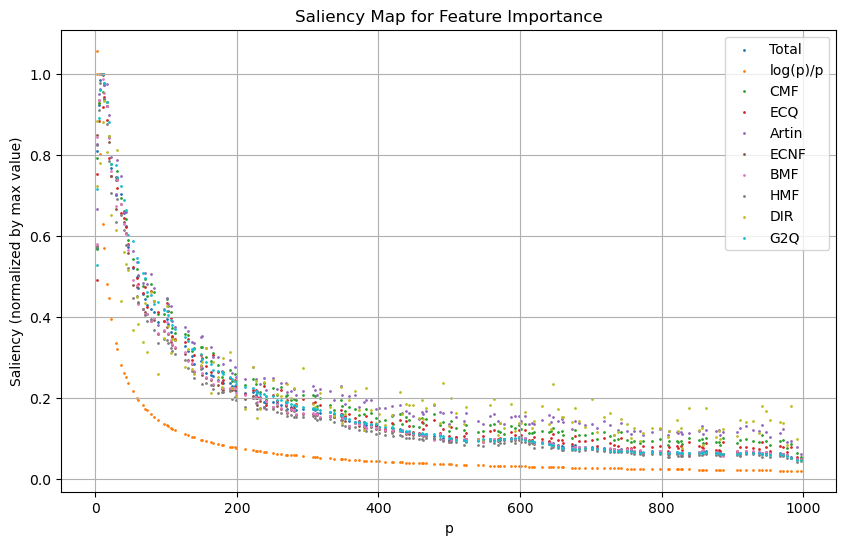

In [18]:
# Plotting train and test accuracy
plt.figure(figsize=(10, 6))
i = 0
plt.plot(range(1, epochs+1), test_accuracy_list[i], label='Total')
for instance_type in possible_instance_types:
    plt.plot(range(0, epochs+1), test_accuracies_type[instance_type], label=f'{instance_type}')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs for Different Types')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
i = 0   
plt.scatter(prime_numbers, saliency_value_list[i], label='Total', s=1)
for instance_type in possible_instance_types:
    plt.scatter(prime_numbers, saliency_type_dict[instance_type], label=f'{instance_type}', s=1)
#plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(10000)), label='log(p)/p', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (Gradient Magnitude)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
i = 0
plt.scatter(prime_numbers, saliency_value_list[i]/np.max(saliency_value_list[i]), label='Total', s=1)
plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(2)/2), label='log(p)/p', s=1)
for instance_type in possible_instance_types:
    plt.scatter(prime_numbers, saliency_type_dict[instance_type]/np.max(saliency_type_dict[instance_type]), 
                label=f'{instance_type}', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

In [19]:
for instance_type in possible_instance_types:
    print(instance_type, f'{test_accuracies_type[instance_type][-1]:.4f}')

CMF 0.9786
ECQ 0.9934
Artin 0.9594
ECNF 0.9623
BMF 0.9627
HMF 0.9609
DIR 1.0000
G2Q 0.9740


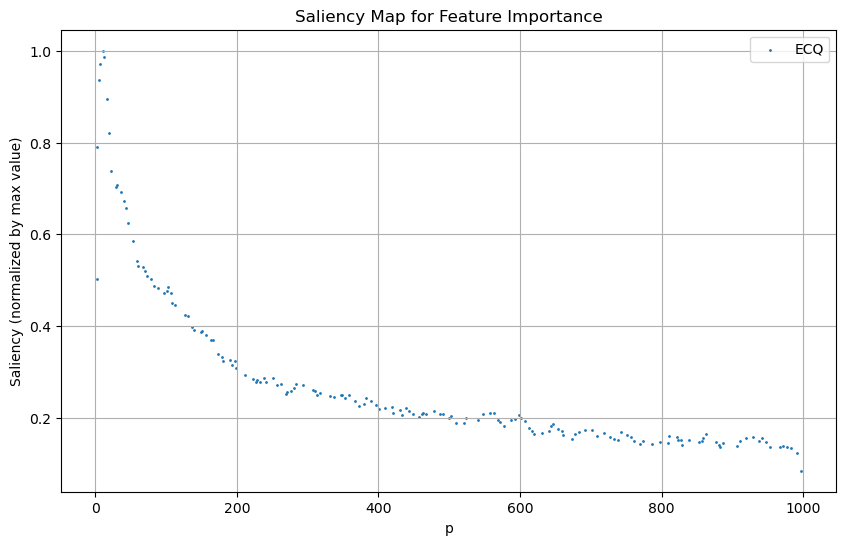

In [51]:
plt.figure(figsize=(10, 6))
prime_numbers = [float(num) for num in feature_columns]
i = 0
#plt.scatter(prime_numbers, saliency_value_list[i]/np.max(saliency_value_list[i]), label='', s=1)
#plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(2)/2), label='log(p)/p', s=1)
for instance_type in ['ECQ']:
    plt.scatter(prime_numbers, saliency_type_dict[instance_type]/np.max(saliency_type_dict[instance_type]), 
                label=f'{instance_type}', s=1)
plt.title('Saliency Map for Feature Importance')
plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
plt.xlabel('p')  # Label for y-axis
plt.legend()
plt.grid(True)
plt.show()

## Training without certain subset

In [46]:
DF = pd.read_table('lfun_rat_ap.txt',delimiter=":",header='infer', low_memory=False)
DF = DF[DF['primitive'] == True]
DF_ap = build_ap_df(DF)
del DF
gc.collect()

7639569

In [47]:
#seed = 11167297796775735125  # Set your desired seed value
seed = 12345
torch.manual_seed(seed)
np.random.seed(1234)

### CMF + ECQ + Artin

In [29]:
# Excluding CMF also excludes all of ECQ and Artin
DF_CMF = DF_ap[DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'CMF' in x).values]
DF_no_CMF = DF_ap[~DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'CMF' in x).values]
DF_train, _ = train_test_split(DF_no_CMF, test_size=0.2, random_state=0)
_, DF_test = train_test_split(DF_CMF, test_size=0.9, random_state=0)

In [30]:
batch_size = 5000
feature_columns = PRIME_COLUMNS[:168]

# Extract feature columns and label
X_train = DF_train[feature_columns].values  # feature_columns are your input features
y_train = DF_train['order_of_vanishing'].values  # This is your label
X_test = DF_test[feature_columns].values  # feature_columns are your input features
y_test = DF_test['order_of_vanishing'].values  # This is your label

#del DF_train, DF_test, DF_ap
#gc.collect()

# Scale the data (optional but recommended for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN (batch_size, channels, sequence_length)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [31]:
max_epochs = 30
saliency_value_list = []
test_accuracy_list = []

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

        # Dummy input to calculate flattened_size
        dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
        self.flattened_size = self._get_flattened_size(dummy_input)

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

        self.dropout = nn.Dropout(0.5)

    def _get_flattened_size(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
        return x.view(1, -1).size(1)  # Flatten and get size
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)  # Apply dropout
        x = torch.relu(self.fc1(x))  # Fully connected layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer
        return x

# Initialize model, loss function, and optimizer
num_classes = 5
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store accuracy values
train_accuracies = []
test_accuracies = []

model.eval()
with torch.no_grad():  
    test_outputs = model(X_test.to(device))
    test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
    test_accuracies.append(test_accuracy)
    
# Training the model
epochs = max_epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    step = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if epoch == 0 and step == 0:
            model.eval()
            with torch.no_grad():
                train_accuracy = calculate_accuracy(labels, outputs)
                train_accuracies.append(train_accuracy)
            model.train()
        step += 1

    model.eval()
    with torch.no_grad():
        # Train accuracy
        #train_outputs = model(X_train)
        #train_accuracy = calculate_accuracy(y_train, train_outputs)
        train_accuracy = calculate_accuracy(labels, outputs)
        train_accuracies.append(train_accuracy)

        # Test accuracy
        test_outputs = model(X_test.to(device))
        test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
        test_accuracies.append(test_accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

test_accuracy_list.append(test_accuracies)
#torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')

    
# Saliency Map Calculation
model.eval()  # Set the model to evaluation mode

# Get a single sample from the test set for saliency calculation
input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

# Forward pass
output = model(input_data.to(device))
_, predicted_class = torch.max(output, 1)  # Get the predicted class index

model.zero_grad()

# Create a one-hot encoding of the predicted classes (this is a binary mask)
one_hot = torch.zeros_like(output)
one_hot[torch.arange(output.size(0)), predicted_class] = 1

# Perform a single backward pass for the entire batch
output.backward(gradient=one_hot, retain_graph=True)

# The gradients for input_data will now be populated for the entire batch
saliency = input_data.grad  # Saliency map for each sample
    
# Average the saliency across the training set
saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()

saliency_value_list.append(saliency)

Epoch [1/30], Loss: 1.1704, Train Accuracy: 0.4944, Test Accuracy: 0.3451
Epoch [2/30], Loss: 0.8443, Train Accuracy: 0.8010, Test Accuracy: 0.8553
Epoch [3/30], Loss: 0.3105, Train Accuracy: 0.9175, Test Accuracy: 0.7723
Epoch [4/30], Loss: 0.2197, Train Accuracy: 0.9331, Test Accuracy: 0.7246
Epoch [5/30], Loss: 0.1877, Train Accuracy: 0.9401, Test Accuracy: 0.8074
Epoch [6/30], Loss: 0.1678, Train Accuracy: 0.9357, Test Accuracy: 0.7530
Epoch [7/30], Loss: 0.1523, Train Accuracy: 0.9496, Test Accuracy: 0.6831
Epoch [8/30], Loss: 0.1491, Train Accuracy: 0.9470, Test Accuracy: 0.6468
Epoch [9/30], Loss: 0.1439, Train Accuracy: 0.9470, Test Accuracy: 0.6740
Epoch [10/30], Loss: 0.1343, Train Accuracy: 0.9444, Test Accuracy: 0.6203
Epoch [11/30], Loss: 0.1313, Train Accuracy: 0.9626, Test Accuracy: 0.6086
Epoch [12/30], Loss: 0.1302, Train Accuracy: 0.9427, Test Accuracy: 0.5839
Epoch [13/30], Loss: 0.1275, Train Accuracy: 0.9600, Test Accuracy: 0.5892
Epoch [14/30], Loss: 0.1236, Train

29 steps per epoch


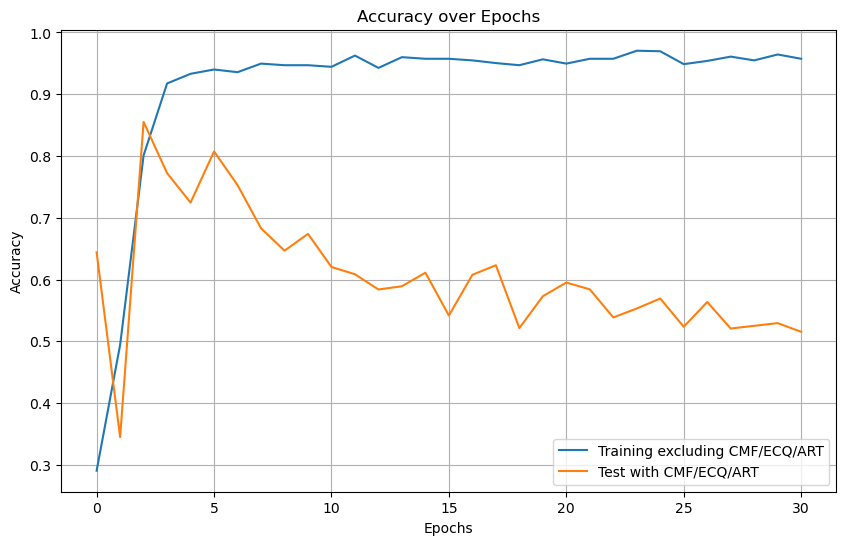

In [32]:
step_per_epoch = math.ceil(len(X_train) / batch_size)
print(f'{step_per_epoch} steps per epoch')
plt.figure(figsize=(10, 6))
i = 0
plt.plot(range(0, epochs+1) , train_accuracies, label='Training excluding CMF/ECQ/ART')
plt.plot(range(0, epochs+1) , test_accuracy_list[i], label='Test with CMF/ECQ/ART')
#plt.plot([epoch*step_per_epoch/10 for epoch in range(1, epochs+1)] , test_accuracy_list[i], label='ECQ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
len(X_train) % 5000

1151

### G2Q

In [33]:
DF_G2Q = DF_ap[DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'G2Q' in x).values]
DF_no_G2Q = DF_ap[~DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'G2Q' in x).values]
DF_train, _ = train_test_split(DF_no_G2Q, test_size=0.2, random_state=0)
_, DF_test = train_test_split(DF_G2Q, test_size=0.9, random_state=0)

In [34]:
batch_size = 5000
feature_columns = PRIME_COLUMNS[:168]

# Extract feature columns and label
X_train = DF_train[feature_columns].values  # feature_columns are your input features
y_train = DF_train['order_of_vanishing'].values  # This is your label
X_test = DF_test[feature_columns].values  # feature_columns are your input features
y_test = DF_test['order_of_vanishing'].values  # This is your label

#del DF_train, DF_test, DF_ap
#gc.collect()

# Scale the data (optional but recommended for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN (batch_size, channels, sequence_length)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [35]:
max_epochs = 30
saliency_value_list = []
test_accuracy_list = []

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

        # Dummy input to calculate flattened_size
        dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
        self.flattened_size = self._get_flattened_size(dummy_input)

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

        self.dropout = nn.Dropout(0.5)

    def _get_flattened_size(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
        return x.view(1, -1).size(1)  # Flatten and get size
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)  # Apply dropout
        x = torch.relu(self.fc1(x))  # Fully connected layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer
        return x

# Initialize model, loss function, and optimizer
num_classes = 5
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store accuracy values
train_accuracies = []
test_accuracies = []

model.eval()
with torch.no_grad():  
    test_outputs = model(X_test.to(device))
    test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
    test_accuracies.append(test_accuracy)
    
# Training the model
epochs = max_epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    step = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if epoch == 0 and step == 0:
            model.eval()
            with torch.no_grad():
                train_accuracy = calculate_accuracy(labels, outputs)
                train_accuracies.append(train_accuracy)
            model.train()
        step += 1

    model.eval()
    with torch.no_grad():
        # Train accuracy
        #train_outputs = model(X_train)
        #train_accuracy = calculate_accuracy(y_train, train_outputs)
        train_accuracy = calculate_accuracy(labels, outputs)
        train_accuracies.append(train_accuracy)

        # Test accuracy
        test_outputs = model(X_test.to(device))
        test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
        test_accuracies.append(test_accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

test_accuracy_list.append(test_accuracies)
#torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')

    
# Saliency Map Calculation
model.eval()  # Set the model to evaluation mode

# Get a single sample from the test set for saliency calculation
input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

# Forward pass
output = model(input_data.to(device))
_, predicted_class = torch.max(output, 1)  # Get the predicted class index

model.zero_grad()

# Create a one-hot encoding of the predicted classes (this is a binary mask)
one_hot = torch.zeros_like(output)
one_hot[torch.arange(output.size(0)), predicted_class] = 1

# Perform a single backward pass for the entire batch
output.backward(gradient=one_hot, retain_graph=True)

# The gradients for input_data will now be populated for the entire batch
saliency = input_data.grad  # Saliency map for each sample
    
# Average the saliency across the training set
saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()

saliency_value_list.append(saliency)

Epoch [1/30], Loss: 1.0889, Train Accuracy: 0.5467, Test Accuracy: 0.4639
Epoch [2/30], Loss: 0.8613, Train Accuracy: 0.6954, Test Accuracy: 0.5561
Epoch [3/30], Loss: 0.6256, Train Accuracy: 0.8385, Test Accuracy: 0.5997
Epoch [4/30], Loss: 0.4005, Train Accuracy: 0.8710, Test Accuracy: 0.6453
Epoch [5/30], Loss: 0.2778, Train Accuracy: 0.9131, Test Accuracy: 0.8592
Epoch [6/30], Loss: 0.2407, Train Accuracy: 0.9180, Test Accuracy: 0.8916
Epoch [7/30], Loss: 0.2140, Train Accuracy: 0.9208, Test Accuracy: 0.8860
Epoch [8/30], Loss: 0.1989, Train Accuracy: 0.9290, Test Accuracy: 0.8838
Epoch [9/30], Loss: 0.1886, Train Accuracy: 0.9342, Test Accuracy: 0.9014
Epoch [10/30], Loss: 0.1808, Train Accuracy: 0.9339, Test Accuracy: 0.9032
Epoch [11/30], Loss: 0.1729, Train Accuracy: 0.9342, Test Accuracy: 0.9047
Epoch [12/30], Loss: 0.1673, Train Accuracy: 0.9358, Test Accuracy: 0.9049
Epoch [13/30], Loss: 0.1663, Train Accuracy: 0.9333, Test Accuracy: 0.9055
Epoch [14/30], Loss: 0.1608, Train

20 steps per epoch


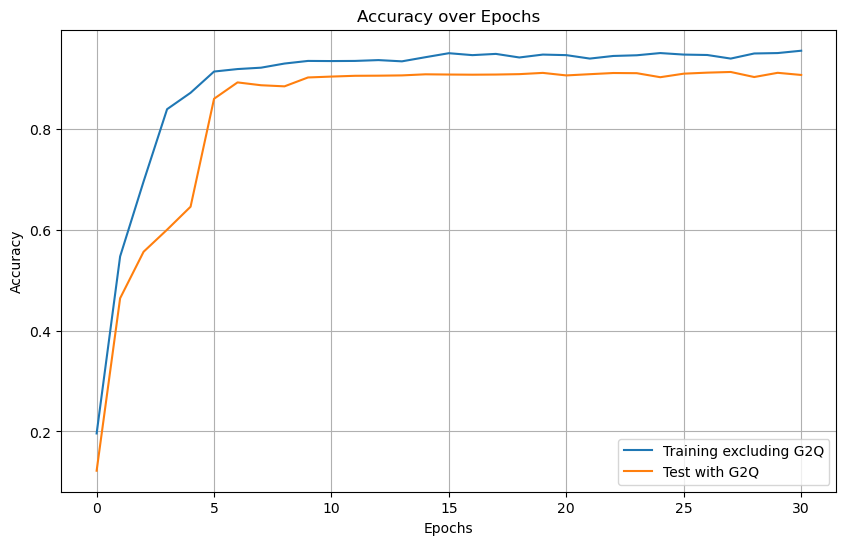

In [36]:
step_per_epoch = math.ceil(len(X_train) / batch_size)
print(f'{step_per_epoch} steps per epoch')
plt.figure(figsize=(10, 6))
i = 0
plt.plot(range(0, epochs+1) , train_accuracies, label='Training excluding G2Q')
plt.plot(range(0, epochs+1) , test_accuracy_list[i], label='Test with G2Q')
#plt.plot([epoch*step_per_epoch/10 for epoch in range(1, epochs+1)] , test_accuracy_list[i], label='ECQ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
len(X_train) % 5000

3660

### ECNF + BMF + HMF

In [38]:
DF_ECNF = DF_ap[DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'ECNF' in x).values]
DF_no_ECNF = DF_ap[~DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'ECNF' in x).values]
DF_train, _ = train_test_split(DF_no_ECNF, test_size=0.2, random_state=0)
_, DF_test = train_test_split(DF_ECNF, test_size=0.4, random_state=0)

In [39]:
batch_size = 5000
feature_columns = PRIME_COLUMNS[:168]

# Extract feature columns and label
X_train = DF_train[feature_columns].values  # feature_columns are your input features
y_train = DF_train['order_of_vanishing'].values  # This is your label
X_test = DF_test[feature_columns].values  # feature_columns are your input features
y_test = DF_test['order_of_vanishing'].values  # This is your label

#del DF_train, DF_test, DF_ap
#gc.collect()

# Scale the data (optional but recommended for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN (batch_size, channels, sequence_length)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [40]:
max_epochs = 40
saliency_value_list = []
test_accuracy_list = []

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

        # Dummy input to calculate flattened_size
        dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
        self.flattened_size = self._get_flattened_size(dummy_input)

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

        self.dropout = nn.Dropout(0.5)

    def _get_flattened_size(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
        return x.view(1, -1).size(1)  # Flatten and get size
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)  # Apply dropout
        x = torch.relu(self.fc1(x))  # Fully connected layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer
        return x

# Initialize model, loss function, and optimizer
num_classes = 5
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store accuracy values
train_accuracies = []
test_accuracies = []

model.eval()
with torch.no_grad():  
    test_outputs = model(X_test.to(device))
    test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
    test_accuracies.append(test_accuracy)
    
# Training the model
epochs = max_epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    step = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if epoch == 0 and step == 0:
            model.eval()
            with torch.no_grad():
                train_accuracy = calculate_accuracy(labels, outputs)
                train_accuracies.append(train_accuracy)
            model.train()
        step += 1

    model.eval()
    with torch.no_grad():
        # Train accuracy
        #train_outputs = model(X_train)
        #train_accuracy = calculate_accuracy(y_train, train_outputs)
        train_accuracy = calculate_accuracy(labels, outputs)
        train_accuracies.append(train_accuracy)

        # Test accuracy
        test_outputs = model(X_test.to(device))
        test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
        test_accuracies.append(test_accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

test_accuracy_list.append(test_accuracies)
#torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')

    
# Saliency Map Calculation
model.eval()  # Set the model to evaluation mode

# Get a single sample from the test set for saliency calculation
input_data = X_test[torch.randperm(X_test.size(0))[:3000]].clone().detach().requires_grad_(True)

# Forward pass
output = model(input_data.to(device))
_, predicted_class = torch.max(output, 1)  # Get the predicted class index

model.zero_grad()

# Create a one-hot encoding of the predicted classes (this is a binary mask)
one_hot = torch.zeros_like(output)
one_hot[torch.arange(output.size(0)), predicted_class] = 1

# Perform a single backward pass for the entire batch
output.backward(gradient=one_hot, retain_graph=True)

# The gradients for input_data will now be populated for the entire batch
saliency = input_data.grad  # Saliency map for each sample
    
# Average the saliency across the training set
saliency = saliency.abs().mean(dim=0).squeeze().detach().cpu().numpy()

saliency_value_list.append(saliency)

Epoch [1/40], Loss: 1.3020, Train Accuracy: 0.4474, Test Accuracy: 0.5387
Epoch [2/40], Loss: 1.1052, Train Accuracy: 0.5084, Test Accuracy: 0.5387
Epoch [3/40], Loss: 0.8599, Train Accuracy: 0.7587, Test Accuracy: 0.8033
Epoch [4/40], Loss: 0.5010, Train Accuracy: 0.8565, Test Accuracy: 0.9079
Epoch [5/40], Loss: 0.3417, Train Accuracy: 0.8810, Test Accuracy: 0.9110
Epoch [6/40], Loss: 0.2911, Train Accuracy: 0.9071, Test Accuracy: 0.9251
Epoch [7/40], Loss: 0.2548, Train Accuracy: 0.9065, Test Accuracy: 0.9218
Epoch [8/40], Loss: 0.2399, Train Accuracy: 0.9055, Test Accuracy: 0.9306
Epoch [9/40], Loss: 0.2296, Train Accuracy: 0.9071, Test Accuracy: 0.9349
Epoch [10/40], Loss: 0.2161, Train Accuracy: 0.9332, Test Accuracy: 0.9379
Epoch [11/40], Loss: 0.2010, Train Accuracy: 0.9226, Test Accuracy: 0.9355
Epoch [12/40], Loss: 0.1918, Train Accuracy: 0.9310, Test Accuracy: 0.9371
Epoch [13/40], Loss: 0.1878, Train Accuracy: 0.9294, Test Accuracy: 0.9422
Epoch [14/40], Loss: 0.1750, Train

12 steps per epoch


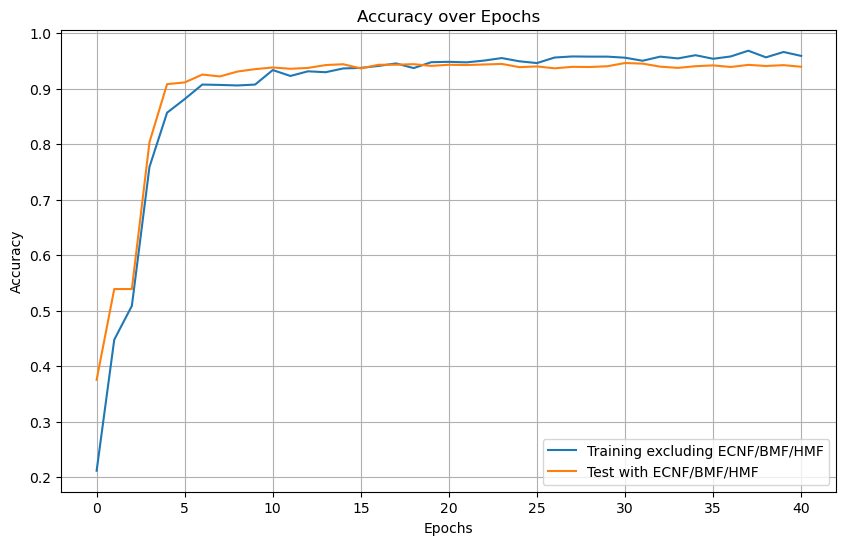

In [41]:
step_per_epoch = math.ceil(len(X_train) / batch_size)
print(f'{step_per_epoch} steps per epoch')
plt.figure(figsize=(10, 6))
i = 0
plt.plot(range(0, epochs+1) , train_accuracies, label='Training excluding ECNF/BMF/HMF')
plt.plot(range(0, epochs+1) , test_accuracy_list[i], label='Test with ECNF/BMF/HMF')
#plt.plot([epoch*step_per_epoch/10 for epoch in range(1, epochs+1)] , test_accuracy_list[i], label='ECQ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
len(X_train) % 5000

3100

### ECQ only

In [48]:
# Excluding CMF also excludes all of ECQ and Artin
DF_ECQ = DF_ap[DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'ECQ' in x).values]
DF_no_CMF = DF_ap[~DF_ap['instance_types'].apply(ast.literal_eval).apply(lambda x: 'CMF' in x).values]
DF_train, _ = train_test_split(DF_no_CMF, test_size=0.2, random_state=0)
_, DF_test = train_test_split(DF_ECQ, test_size=0.9, random_state=0)

In [49]:
batch_size = 5000
feature_columns = PRIME_COLUMNS[:168]

# Extract feature columns and label
X_train = DF_train[feature_columns].values  # feature_columns are your input features
y_train = DF_train['order_of_vanishing'].values  # This is your label
X_test = DF_test[feature_columns].values  # feature_columns are your input features
y_test = DF_test['order_of_vanishing'].values  # This is your label

#del DF_train, DF_test, DF_ap
#gc.collect()

# Scale the data (optional but recommended for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN (batch_size, channels, sequence_length)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])  # 1 channel
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])  # 1 channel

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [50]:
max_epochs = 60
saliency_value_list = []
test_accuracy_list = []

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # Larger kernel size
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, padding=1)

        # Dummy input to calculate flattened_size
        dummy_input = torch.zeros(1, 1, X_train.shape[-1])  # Example input size (batch_size, channels, length)
        self.flattened_size = self._get_flattened_size(dummy_input)

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)  # Final output layer for classification

        self.dropout = nn.Dropout(0.5)

    def _get_flattened_size(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling           
        return x.view(1, -1).size(1)  # Flatten and get size
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # First conv layer + pooling
        x = self.pool(torch.relu(self.conv2(x)))  # Second conv layer + pooling
        x = self.pool(torch.relu(self.conv3(x)))  # Third conv layer + pooling

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)  # Apply dropout
        x = torch.relu(self.fc1(x))  # Fully connected layer
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output layer
        return x

# Initialize model, loss function, and optimizer
num_classes = 5
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store accuracy values
train_accuracies = []
test_accuracies = []

# Training the model
epochs = max_epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    test_accuracy_steps = []
    step = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
            test_accuracy_steps.append(test_accuracy)

        torch.save(model.state_dict(), f'Conductor_models/{epoch}_{step}.pth')
        model.train()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        step += 1
        
    model.eval()
    with torch.no_grad():
        # Train accuracy
        #train_outputs = model(X_train)
        #train_accuracy = calculate_accuracy(y_train, train_outputs)
        train_accuracy = calculate_accuracy(labels, outputs)
        train_accuracies.append(train_accuracy)

        # Test accuracy
        test_outputs = model(X_test.to(device))
        test_accuracy = calculate_accuracy(y_test.to(device), test_outputs)
        test_accuracies.append(test_accuracy)

    # Print every 10 epochs
    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
              f'Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

    test_accuracy_list.append(test_accuracy_steps)
#torch.save(model.state_dict(), f'Conductor_models/CNN_{conductor_min}_to_{conductor_min}.pth')



Epoch [1/60], Loss: 1.1704, Train Accuracy: 0.4944, Test Accuracy: 0.4903
Epoch [2/60], Loss: 0.8443, Train Accuracy: 0.8010, Test Accuracy: 0.9763
Epoch [3/60], Loss: 0.3105, Train Accuracy: 0.9175, Test Accuracy: 0.9727
Epoch [4/60], Loss: 0.2197, Train Accuracy: 0.9322, Test Accuracy: 0.9308
Epoch [5/60], Loss: 0.1877, Train Accuracy: 0.9401, Test Accuracy: 0.9357
Epoch [6/60], Loss: 0.1679, Train Accuracy: 0.9357, Test Accuracy: 0.8641
Epoch [7/60], Loss: 0.1524, Train Accuracy: 0.9505, Test Accuracy: 0.7199
Epoch [8/60], Loss: 0.1493, Train Accuracy: 0.9470, Test Accuracy: 0.7429
Epoch [9/60], Loss: 0.1441, Train Accuracy: 0.9470, Test Accuracy: 0.7008
Epoch [10/60], Loss: 0.1345, Train Accuracy: 0.9435, Test Accuracy: 0.6771
Epoch [11/60], Loss: 0.1310, Train Accuracy: 0.9635, Test Accuracy: 0.6627
Epoch [12/60], Loss: 0.1298, Train Accuracy: 0.9427, Test Accuracy: 0.5933
Epoch [13/60], Loss: 0.1272, Train Accuracy: 0.9592, Test Accuracy: 0.6521
Epoch [14/60], Loss: 0.1233, Train

NameError: name 'y' is not defined

<Figure size 1000x700 with 0 Axes>

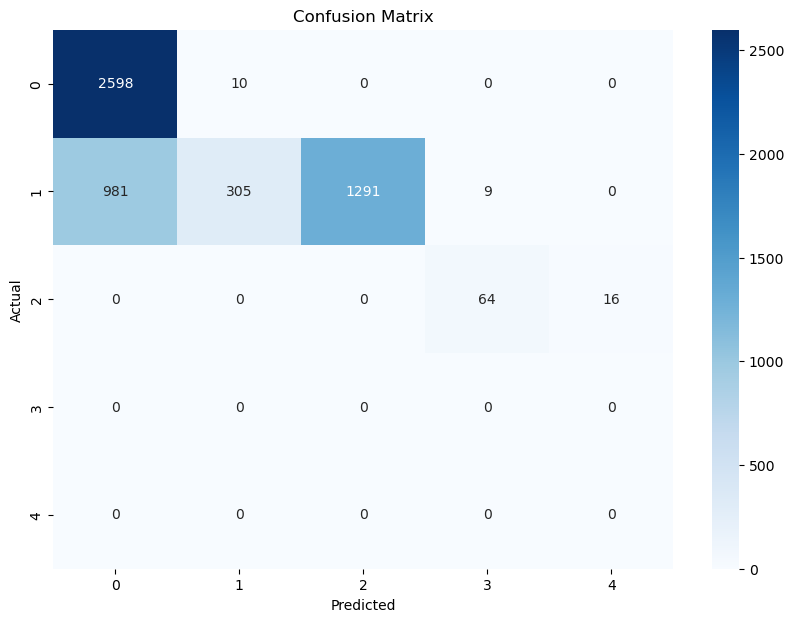

In [53]:
# Confusion matrix
_, y_predicted = torch.max(test_outputs, 1)
cm = confusion_matrix(y_test.to('cpu'), y_predicted.to('cpu'))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels={0,1,2,3,4}, yticklabels={0,1,2,3,4})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

29 steps per epoch


ValueError: x and y must have same first dimension, but have shapes (60,) and (29,)

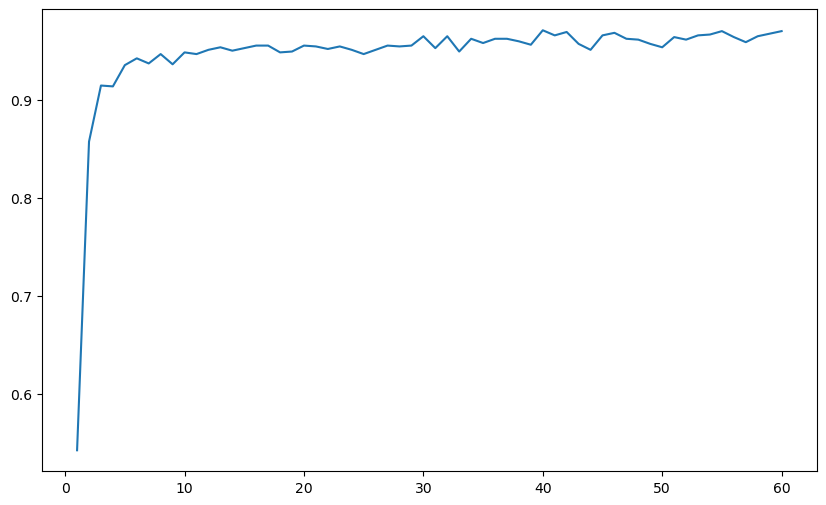

In [25]:
step_per_epoch = math.ceil(len(X_train) / batch_size)
print(f'{step_per_epoch} steps per epoch')
plt.figure(figsize=(10, 6))
i = 0
plt.plot(range(1, epochs+1) , train_accuracies, label='Training excluding CMF/ECQ/ART')
plt.plot(range(1, epochs+1) , test_accuracy_list[i], label='Test with ECQ')
#plt.plot([epoch*step_per_epoch/10 for epoch in range(1, epochs+1)] , test_accuracy_list[i], label='ECQ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
len(X_train) % 5000

1151

In [45]:
prime_numbers = [float(num) for num in feature_columns]

for epoch in range(60):
    print(f'Epoch: {epoch}')
    for step in range(29):     
        model = CNN(5).to(device)
        model.load_state_dict(torch.load(f'Conductor_models/{epoch}_{step}.pth', weights_only=True))

        # Saliency Map Calculation
        model.eval()  # Set the model to evaluation mode

        # Get a single sample from the test set for saliency calculation
        input_data = X_train[torch.randperm(X_train.size(0))[:3000]].clone().detach().requires_grad_(True)
        
        # Forward pass
        output = model(input_data.to(device))
        _, predicted_class = torch.max(output, 1)  # Get the predicted class index

        # Compute the gradients of the predicted class with respect to the input
        #saliency = torch.zeros_like(input_data)  # Placeholder for saliency values
        class_saliency = [[] for _ in range(num_classes)]

        model.zero_grad()
        
        # Create a one-hot encoding of the predicted classes (this is a binary mask)
        one_hot = torch.zeros_like(output)
        one_hot[torch.arange(output.size(0)), predicted_class] = 1
        
        # Perform a single backward pass for the entire batch
        output.backward(gradient=one_hot, retain_graph=True)
        
        # The gradients for input_data will now be populated for the entire batch
        saliency = input_data.grad  # Saliency map for each sample
        for i in range(output.size(0)):
            class_saliency[predicted_class[i].item()].append(saliency[i])

        # Plotting
        plt.figure(figsize=(10, 6))
        for order in range(len(class_saliency)):
            try:
                saliency_y = torch.stack(class_saliency[order]).mean(dim=0).squeeze().cpu().numpy()
                plt.scatter(prime_numbers, saliency_y/(np.max(np.abs(saliency_y))), label=f'{order}', c=f'C{order}', s=1)
            except:
                pass
        #plt.scatter(prime_numbers, np.log(prime_numbers) / prime_numbers / (np.log(2)/2), label='log(p)/p', s=1)
        plt.title(f'Saliency Map for Feature Importance')
        plt.ylabel('Saliency (normalized by max value)')  # Label for x-axis
        plt.xlabel('p')  # Label for y-axis
        plt.ylim(-1, 1)
        plt.legend()
        plt.grid(True)
        plt.text(0.75, 0.10, f'Epoch {epoch}, Step {step}, Accuracy: {test_accuracy_list[epoch][step]:.4f} ', ha='center', va='center', 
                 fontsize=12, color='black', transform=plt.gca().transAxes, fontweight='bold')
        plt.savefig(f"Saliency_plots/{epoch}_{step}.pdf", dpi=300, bbox_inches='tight')
        plt.close()

Epoch: 0
Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10
Epoch: 11
Epoch: 12
Epoch: 13
Epoch: 14
Epoch: 15
Epoch: 16
Epoch: 17
Epoch: 18
Epoch: 19
Epoch: 20
Epoch: 21
Epoch: 22
Epoch: 23
Epoch: 24
Epoch: 25
Epoch: 26
Epoch: 27
Epoch: 28
Epoch: 29
Epoch: 30
Epoch: 31
Epoch: 32
Epoch: 33
Epoch: 34
Epoch: 35
Epoch: 36
Epoch: 37
Epoch: 38
Epoch: 39
Epoch: 40
Epoch: 41
Epoch: 42
Epoch: 43
Epoch: 44
Epoch: 45
Epoch: 46
Epoch: 47
Epoch: 48
Epoch: 49
Epoch: 50
Epoch: 51
Epoch: 52
Epoch: 53
Epoch: 54
Epoch: 55
Epoch: 56
Epoch: 57
Epoch: 58
Epoch: 59


In [ ]:
compute_instance_type_stats(DF_train, 'instance_types', possible_instance_types)

In [90]:
#DF_PCA = DF_ap[(DF_ap['motivic_weight']==1) & (DF_ap['degree']==4)]
DF_PCA = DF_ap[DF_ap['degree']==1]
#DF_PCA = DF_ap[(DF_ap['motivic_weight']==1) & (DF_ap['degree']==2)]
#DF_PCA = DF_ap[ (DF_ap['degree']==4) | (DF_ap['degree']==2)]
#DF_PCA = DF_ap

In [91]:
compute_instance_type_stats(DF_PCA, 'instance_types', possible_instance_types)

CMF: 0
ECQ: 0
Artin: 1
ECNF: 0
BMF: 0
HMF: 0
DIR: 274
G2Q: 0


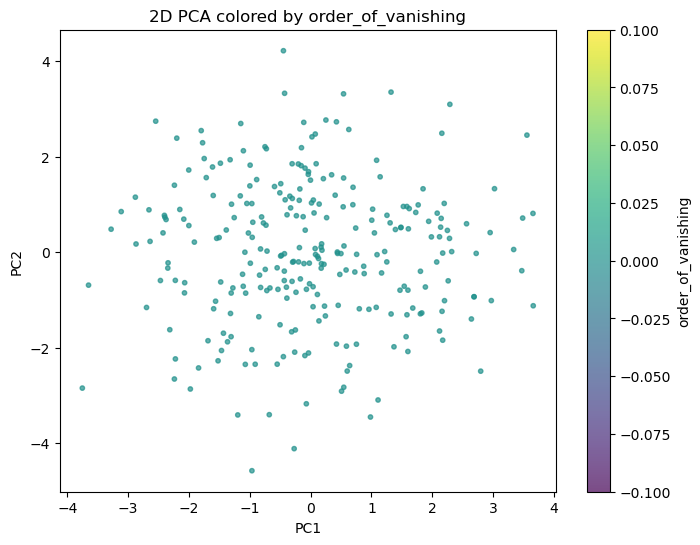

In [92]:
feature_columns = PRIME_COLUMNS[:168]
X = DF_PCA[feature_columns]
y = DF_PCA['label']
pca = PCA(n_components=168)
principal_components = pca.fit_transform(X)

pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(len(feature_columns))])
pca_df['label'] = y.values

col = 'order_of_vanishing'
vals = DF_PCA[col].value_counts()

color = DF_PCA[col]

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=color, alpha=0.7, s=10, cmap='viridis')

# Add labels and title
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f'2D PCA colored by {col}')

# Add color bar
plt.colorbar(label=col)

# Show the plot
plt.show()

In [83]:
#DF_PCA = DF_ap[(DF_ap['motivic_weight']==1) & (DF_ap['degree']==4)]
#DF_PCA = DF_ap[DF_ap['degree']==1]
#DF_PCA = DF_ap[(DF_ap['motivic_weight']==1) & (DF_ap['degree']==2)]
DF_PCA = DF_ap[ (DF_ap['degree']==4)]
#DF_PCA = DF_ap

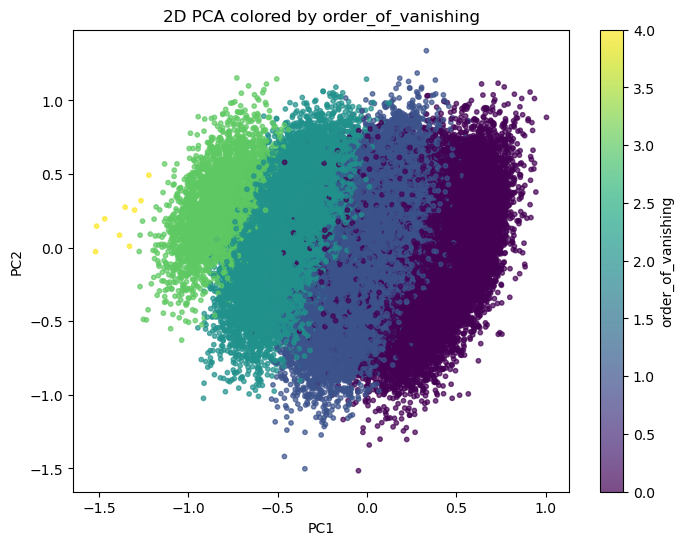

In [84]:
feature_columns = PRIME_COLUMNS[:168]
X = DF_PCA[feature_columns]
y = DF_PCA['label']
pca = PCA(n_components=168)
principal_components = pca.fit_transform(X)

pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(len(feature_columns))])
pca_df['label'] = y.values

col = 'order_of_vanishing'
vals = DF_PCA[col].value_counts()

color = DF_PCA[col]

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=color, alpha=0.7, s=10, cmap='viridis')

# Add labels and title
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f'2D PCA colored by {col}')

# Add color bar
plt.colorbar(label=col)

# Show the plot
plt.show()